## 🇮🇪 Ireland Population & Demographic Analysis
### Exploratory Data Analysis and Machine Learning Modelling of Ireland Census Data

**Author:** Rosilene Francisca  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy  
**Dataset:** CSO Ireland Population Census Data (2011, 2016, 2022)

# 1. Business Understanding

This project analyses Irish population data from the Central Statistics Office (CSO) to identify demographic trends across census years, counties/cities, gender, age groups, and marital status.

The project combines data cleaning, exploratory data analysis (EDA), statistical analysis, data visualisation, and supervised machine learning techniques to transform raw census data into meaningful insights and predictive models.

## Key Questions

- How has Ireland’s population changed across the 2011, 2016, and 2022 census years?
- Which counties or cities show the highest population concentration?
- How does population vary across age groups, gender, and marital status categories?
- What demographic patterns can support public planning and decision-making?
- Can demographic variables be used to predict gender categories using machine learning models?

## 2. Data Understanding

The dataset was obtained from the Central Statistics Office (CSO) Ireland. It contains population census data for 2011, 2016, and 2022.

The dataset includes demographic information such as census year, marital status, county/city, gender, age group, and population value.

**Dataset Source:** Central Statistics Office Ireland  
**Table:** FY008B Population 2011, 2016, 2022  
**Link:** https://data.cso.ie/table/FY008B

/ Python Tool and Library Implementation
/ Exploratory Data Analysis (EDA)
/ Statistics 
/ Observing and describing the dataset

### Importing Required Libraries

The following libraries were used for data manipulation, statistical analysis, and visualisation.

In [1]:
#Importing the essential libraries, which are Pandas, Matplotlib, Seaborn, and Numpy.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style
from matplotlib import cm

%matplotlib inline

#Warnings: It can handle alert and warning messages with a number of commands and functions.
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Command to display all columns in the file.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

It is time to read the file/dataset now that the libraries have been imported. The file is in '.csv' format, which is a cost-effective way to store data in tables. The pandas library contains a function called `.read_csv()` that can read this sort of file and transform it into a DataFrame. So let's read the dataset and then visualise it using the df.head() function.

In [3]:
# Importing the Dataset 
datapop_df = pd.read_csv("irelandpopulation.csv")

### Dataset Preview

In [4]:
datapop_df.head()

,Statistic Label,CensusYear,Detailed Marital Status,County and City,Sex,Age Group,UNIT,VALUE
0,Population,2011,All marital status,State,Both sexes,All ages,Number,4588252
1,Population,2011,All marital status,State,Both sexes,Under 25 years,Number,1559840
2,Population,2011,All marital status,State,Both sexes,25 - 29 years,Number,361122
3,Population,2011,All marital status,State,Both sexes,30 - 34 years,Number,393945
4,Population,2011,All marital status,State,Both sexes,35 - 39 years,Number,364261


The first rows of the dataset were displayed to understand its structure and available features.

In [5]:
datapop_df.tail()

,Statistic Label,CensusYear,Detailed Marital Status,County and City,Sex,Age Group,UNIT,VALUE
33475,Population,2022,Widowed,Monaghan,Female,65 - 69 years,Number,201
33476,Population,2022,Widowed,Monaghan,Female,70 - 74 years,Number,332
33477,Population,2022,Widowed,Monaghan,Female,75 - 79 years,Number,359
33478,Population,2022,Widowed,Monaghan,Female,80 - 84 years,Number,363
33479,Population,2022,Widowed,Monaghan,Female,85 years and over,Number,522


The last rows were reviewed to confirm the dataset structure remained consistent throughout the file.

In [6]:
 # Display the dimensions of the Dataset
datapop_df.shape

(33480, 8)

The dataset contains **33,480 rows** and **8 columns**, representing population records across census years and demographic categories.

In [7]:
datapop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33480 entries, 0 to 33479
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Statistic Label          33480 non-null  object
 1   CensusYear               33480 non-null  int64 
 2   Detailed Marital Status  33480 non-null  object
 3   County and City          33480 non-null  object
 4   Sex                      33480 non-null  object
 5   Age Group                33480 non-null  object
 6   UNIT                     33480 non-null  object
 7   VALUE                    33480 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 2.0+ MB


The dataset contains both categorical and numerical variables. There are no missing values in the columns, and the main numerical fields are `CensusYear` and `VALUE`.

### Data Types

In [8]:
datapop_df.dtypes

Statistic Label            object
CensusYear                  int64
Detailed Marital Status    object
County and City            object
Sex                        object
Age Group                  object
UNIT                       object
VALUE                       int64
dtype: object

The data types of each column were examined to distinguish between numerical and categorical variables.

In [9]:
datapop_df.nunique()

Statistic Label               1
CensusYear                    3
Detailed Marital Status       8
County and City              31
Sex                           3
Age Group                    15
UNIT                          1
VALUE                      7835
dtype: int64

Analysing unique values and category frequencies helps identify the distribution and structure of variables within the dataset.

In [10]:
## Counting unique values in numerical columns
datapop_df.select_dtypes(include='number').nunique()  

CensusYear       3
VALUE         7835
dtype: int64

The dataset contains a limited number of census years and demographic categories, while the `VALUE` column shows high variability due to the wide range of population counts.

## 3. Data Preparation

### Exploratory Data Analysis (EDA) and Data Cleaning

#### Missing Value Analysis

#### Verifying null values in the dataset
We may check for null values in the datasets in a variety of ways; I chose these to determine whether there are any missing values in the datasets.

In [11]:
datapop_df.isnull().sum()

Statistic Label            0
CensusYear                 0
Detailed Marital Status    0
County and City            0
Sex                        0
Age Group                  0
UNIT                       0
VALUE                      0
dtype: int64

In [12]:
popnull = datapop_df.isna().sum().sum()
print ('Null values in datapop: {}'.format(popnull))

Null values in datapop: 0


In [13]:
datapop_df.isnull().values.any()

False

The dataset was checked for missing values to ensure data quality before performing further analysis and visualisation.
The dataset contains no missing values, so no imputation or row removal was necessary.

### Initial Data Inspection

Specific rows and columns were selected to inspect demographic categories and population values more closely.

In [14]:
selected_column = datapop_df['Detailed Marital Status']
selected_column.head()

0    All marital status
1    All marital status
2    All marital status
3    All marital status
4    All marital status
Name: Detailed Marital Status, dtype: object

In [15]:
selected_data2 = datapop_df.loc[[1, 33479], ['Detailed Marital Status', 'VALUE']]
print(selected_data2)

      Detailed Marital Status    VALUE
1          All marital status  1559840
33479                 Widowed      522


Additional records were inspected to validate the structure and consistency of the dataset across different observations.

### Population Analysis for Age Group 85 Years and Over

The dataset was filtered to analyse records related to the population aged 85 years and over. This allows the identification of ageing population trends across census years.

In [16]:
selected_data3 = datapop_df.loc[datapop_df['Age Group'].isin(['85 years and over']),
                               ['Age Group', 'VALUE']]
selected_data3.head()

,Age Group,VALUE
14,85 years and over,58416
29,85 years and over,18486
44,85 years and over,39930
59,85 years and over,646
74,85 years and over,222


In [17]:
population_by_census = datapop_df[datapop_df['Age Group'] == '85 years and over'].groupby('CensusYear')['VALUE'].sum()
population_by_census.head()

CensusYear
2011    467328
2016    540440
2022    675528
Name: VALUE, dtype: int64

The results show a continuous increase in the population aged 85 years and over between the 2011, 2016, and 2022 census years, indicating an ageing population trend in Ireland.

In [18]:
value_sum = selected_data3['VALUE'].sum()
print(f"Sum of Population for 85 years and over: {value_sum}")

Sum of Population for 85 years and over: 1683296


The total population for individuals aged 85 years and over was calculated to support demographic trend analysis across census periods.

### Duplicate Record Analysis

In [19]:
# Identifying duplicates (change 'keep' to 'first', 'last', or False if appropriate)
duplicates = datapop_df.duplicated(keep=False)
print('Duplicates rows:')
print(datapop_df[duplicates])

Duplicates rows:
Empty DataFrame
Columns: [Statistic Label, CensusYear, Detailed Marital Status, County and City, Sex, Age Group, UNIT, VALUE]
Index: []


In [20]:
# Finding duplication according to columns
duplicates = datapop_df.duplicated(subset=['Statistic Label', 'CensusYear', 'Detailed Marital Status','County and City',
                                   'Sex', 'Age Group','UNIT', 'VALUE'], keep=False)
print('Duplicates rows:')
print(datapop_df[duplicates])

Duplicates rows:
Empty DataFrame
Columns: [Statistic Label, CensusYear, Detailed Marital Status, County and City, Sex, Age Group, UNIT, VALUE]
Index: []


Duplicate records were checked to ensure data consistency and avoid repeated observations affecting the analysis. 
No duplicate records were identified in the dataset.

### Column Renaming

Several columns were renamed to improve readability and simplify the analysis process.

In [21]:
datapop_df.rename(columns={'Detailed Marital Status': 'MaritalStatus', 'County and City': 'Area', 
                           'Sex': 'Gender','Age Group': 'AgeGroup', 'VALUE': 'UnitValue' }, inplace = True)
datapop_df.head(2)

,Statistic Label,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UNIT,UnitValue
0,Population,2011,All marital status,State,Both sexes,All ages,Number,4588252
1,Population,2011,All marital status,State,Both sexes,Under 25 years,Number,1559840


In [22]:
datapop_df.shape

(33480, 8)

### Standardising Categorical Values

Several categorical values were standardised to improve consistency and readability within the dataset.

In [23]:
print(datapop_df.MaritalStatus.unique())

['All marital status' 'Single' 'Registered same-sex civil partnership'
 'Married (first marriage)' 'Re-married' 'Separated' 'Divorced' 'Widowed']


In [24]:
datapop_df['MaritalStatus'].replace({'Re-married': 'Remarried', 'Registered same-sex civil partnership': 'Registered Same Sex',
                                     'Married (first marriage)':'Married'}, inplace=True)
print(datapop_df.MaritalStatus.nunique())

8


In [25]:
# Distribution of marital status categories
datapop_df['MaritalStatus'].value_counts()

MaritalStatus
All marital status     4185
Single                 4185
Registered Same Sex    4185
Married                4185
Remarried              4185
Separated              4185
Divorced               4185
Widowed                4185
Name: count, dtype: int64

The marital status categories are evenly distributed because the dataset structure contains repeated demographic combinations across census years and regions.

### Standardising Area Names

Some area names were simplified to improve readability and consistency in visualisations and analysis outputs.

In [26]:
print(datapop_df.Area.unique())

['State' 'Carlow' 'Dublin City' 'Dún Laoghaire-Rathdown' 'Fingal'
 'South Dublin' 'Kildare' 'Kilkenny' 'Laois' 'Longford' 'Louth' 'Meath'
 'Offaly' 'Westmeath' 'Wexford' 'Wicklow' 'Clare'
 'Cork City and Cork County' 'Kerry' 'Limerick City and County'
 'Tipperary' 'Waterford City and County' 'Galway City' 'Galway County'
 'Leitrim' 'Mayo' 'Roscommon' 'Sligo' 'Cavan' 'Donegal' 'Monaghan']


In [27]:
datapop_df['Area'].replace({'Dún Laoghaire-Rathdown': 'Dun Laoghaire', 'Cork City and Cork County': 'Cork',
                                     'Limerick City and County':'Limerick','Waterford City and County':'Waterford'}, inplace=True)
print(datapop_df.Area.nunique())

31


In [28]:
print(datapop_df.Area.unique())

['State' 'Carlow' 'Dublin City' 'Dun Laoghaire' 'Fingal' 'South Dublin'
 'Kildare' 'Kilkenny' 'Laois' 'Longford' 'Louth' 'Meath' 'Offaly'
 'Westmeath' 'Wexford' 'Wicklow' 'Clare' 'Cork' 'Kerry' 'Limerick'
 'Tipperary' 'Waterford' 'Galway City' 'Galway County' 'Leitrim' 'Mayo'
 'Roscommon' 'Sligo' 'Cavan' 'Donegal' 'Monaghan']


The area names were cleaned and simplified while preserving the total number of geographic categories in the dataset.

## Descriptive Statistics

The dataset was sorted by `UnitValue` to inspect the highest and lowest population values. This helps identify aggregate records, zero values, and potential outliers before deeper analysis.

In [29]:
datapop_df.sort_values('UnitValue', ascending=False, inplace=True)
datapop_df.head()

,Statistic Label,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UNIT,UnitValue
22320,Population,2022,All marital status,State,Both sexes,All ages,Number,5149139
11160,Population,2016,All marital status,State,Both sexes,All ages,Number,4761865
0,Population,2011,All marital status,State,Both sexes,All ages,Number,4588252
23715,Population,2022,Single,State,Both sexes,All ages,Number,2773334
22350,Population,2022,All marital status,State,Female,All ages,Number,2604590


The highest values correspond to aggregated records such as `State`, `All marital status`, `Both sexes`, and `All ages`. These records represent totals and need to be handled carefully to avoid double-counting in later analysis.

The dataset was then sorted in ascending order to inspect records with the lowest population values.

In [30]:
datapop_df.sort_values('UnitValue', ascending=True, inplace=True)
datapop_df.head()

,Statistic Label,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UNIT,UnitValue
14233,Population,2016,Registered Same Sex,Kildare,Both sexes,80 - 84 years,Number,0
14547,Population,2016,Registered Same Sex,Westmeath,Both sexes,75 - 79 years,Number,0
14546,Population,2016,Registered Same Sex,Westmeath,Both sexes,70 - 74 years,Number,0
14544,Population,2016,Registered Same Sex,Westmeath,Both sexes,60 - 64 years,Number,0
15238,Population,2016,Registered Same Sex,Cavan,Male,80 - 84 years,Number,0


Several zero values appear in records related to the `Registered Same Sex` marital status category. These values may be valid due to the historical context of same-sex marriage legislation in Ireland, but they should be interpreted carefully alongside other demographic variables.

In [31]:
#Summary statistics for numerical variables
datapop_df.describe()

,CensusYear,UnitValue
count,33480.000000,3.348000e+04
mean,2016.333333,6.929155e+03
std,4.496980,7.477497e+04
min,2011.000000,0.000000e+00
25%,2011.000000,2.600000e+01
50%,2016.000000,2.340000e+02
75%,2022.000000,1.720000e+03
max,2022.000000,5.149139e+06


The summary statistics show that `UnitValue` has a wide range, from 0 to more than 5 million. This confirms the presence of aggregate records and large population totals in the dataset.

In [32]:
# Getting summary statistics
datapop_df.describe().transpose().style.background_gradient(cmap= 'Blues')

,count,mean,std,min,25%,50%,75%,max
CensusYear,33480.000000,2016.333333,4.496980,2011.000000,2011.000000,2016.000000,2022.000000,2022.000000
UnitValue,33480.000000,6929.154600,74774.974254,0.000000,26.000000,234.000000,1720.000000,5149139.000000


The `UnitValue` variable was further examined to understand its minimum, maximum, average, median, variance, and mode.

In [33]:
print('Minimum Value: ', datapop_df['UnitValue'].min())
print('Maximum Value: ', datapop_df['UnitValue'].max())
print('Average Value:' , datapop_df['UnitValue'].mean())
print('Median Value:', datapop_df['UnitValue'].median())
print('Variance Value:', datapop_df['UnitValue'].var())
print('Mode Value:', datapop_df['UnitValue'].mode())

Minimum Value:  0
Maximum Value:  5149139
Average Value: 6929.154599761051
Median Value: 234.0
Variance Value: 5591296774.710052
Mode Value: 0    0
Name: UnitValue, dtype: int64


The large difference between the median and maximum values suggests that population totals are highly skewed due to aggregate categories and regional population differences.

### Categorical Variable Summary

Summary statistics for categorical variables were examined to understand the distribution and frequency of demographic categories within the dataset.

In [34]:
datapop_df.describe(include=object)

,Statistic Label,MaritalStatus,Area,Gender,AgeGroup,UNIT
count,33480,33480,33480,33480,33480,33480
unique,1,8,31,3,15,1
top,Population,Registered Same Sex,Kildare,Both sexes,80 - 84 years,Number
freq,33480,4185,1080,11160,2232,33480


The categorical summary confirms that the dataset contains complete records across all demographic categories. It also highlights the most frequent values and the number of unique categories for variables such as marital status, area, gender, and age group.

### Skewness Analysis

Skewness was calculated to evaluate the asymmetry of the `UnitValue` distribution.

In [35]:
skewness = datapop_df['UnitValue'].skew()
print('Skewness is', skewness)

Skewness is 38.81706592209606


The `UnitValue` variable shows very high positive skewness, indicating that most records contain relatively small population values while a smaller number of aggregate records contain extremely large values.

### Kurtosis Analysis

Kurtosis was calculated to assess the presence of extreme values and heavy tails in the population distribution.

In [36]:
kurtosis = datapop_df['UnitValue'].kurtosis()
print('Kurtosis value is', kurtosis)

Kurtosis value is 1990.9066682378395


The extremely high kurtosis value confirms the presence of strong outliers and highly concentrated population totals within the dataset. These results suggest that aggregate demographic categories significantly influence the distribution.

### Population Distribution by Area

Population totals were aggregated by area to identify regions with the highest and lowest population concentrations across census periods.

In [37]:
value_counties = datapop_df.groupby('Area')[['UnitValue']].sum() 
print(value_counties.sort_values(by = ['UnitValue']))

               UnitValue
Area                    
Leitrim           792328
Longford         1012992
Carlow           1388096
Monaghan         1497256
Roscommon        1590944
Sligo            1609008
Cavan            1848504
Offaly           1902384
Galway City      1908888
Laois            2057064
Westmeath        2169240
Kilkenny         2390488
Waterford        2858672
Clare            2911608
Louth            3131872
Mayo             3192920
Wicklow          3479328
Kerry            3597336
Wexford          3671688
Tipperary        3889616
Donegal          3899304
Galway County    4382696
Limerick         4769952
Meath            4800040
Dun Laoghaire    5265112
Kildare          5444720
South Dublin     6760376
Fingal           7204136
Cork            13168448
Dublin City     13399032
State          115994048


The results show that Dublin City and Cork have the highest population totals, while smaller counties such as Leitrim and Longford contain lower population values. The `State` category represents the overall national population total.

In [38]:
count = (datapop_df['Area'] == 'Dublin City').sum()
count

1080

This confirms the number of records associated with Dublin City in the dataset.

In [39]:
# Distribution of gender categories
datapop_df['Gender'].value_counts()

Gender
Both sexes    11160
Male          11160
Female        11160
Name: count, dtype: int64

The gender categories are evenly distributed because the dataset structure contains repeated demographic combinations across census years and regions.

### Distribution of Categorical Variables

Count plots were used to examine the distribution of key categorical variables, including marital status, age group, gender, and geographic area.

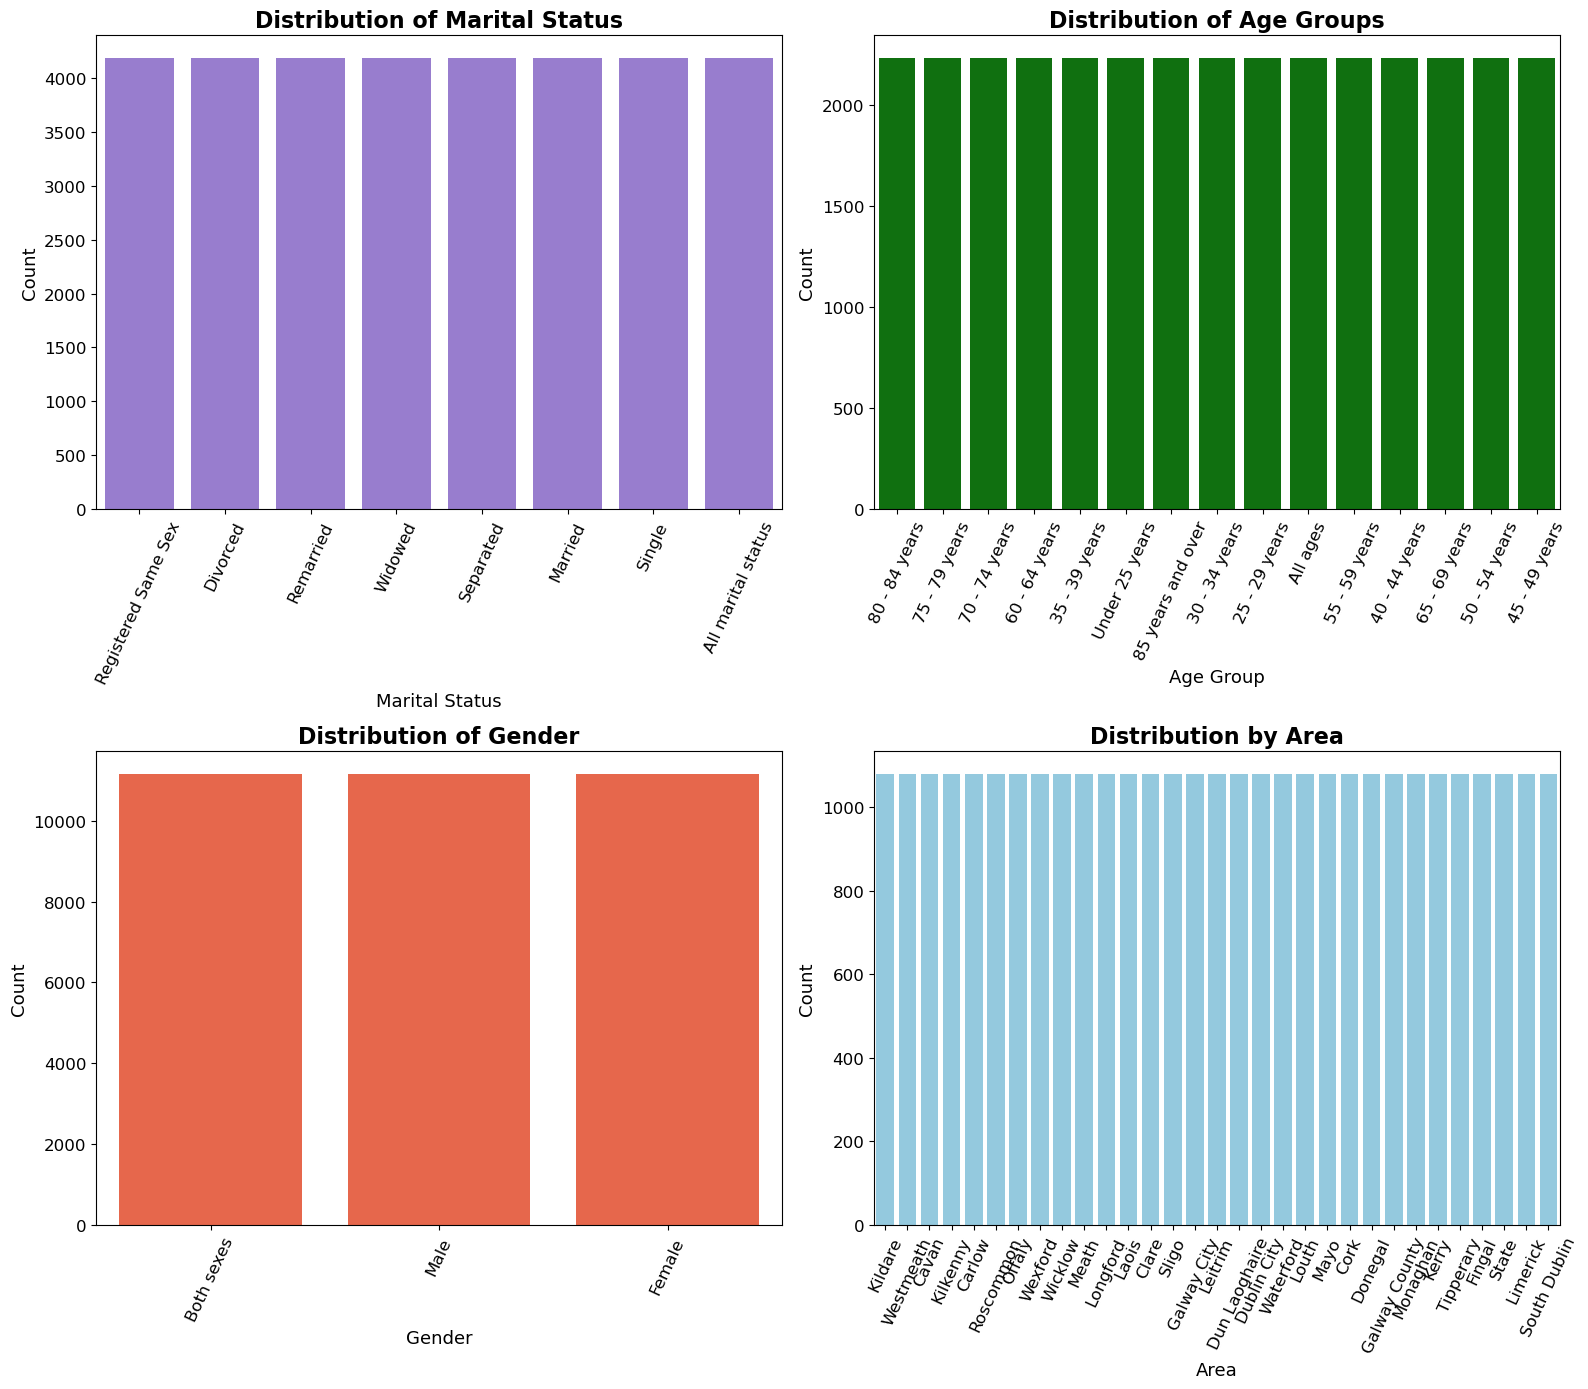

In [40]:
plt.rcParams['figure.figsize'] = [16, 14]
plt.rcParams['figure.autolayout'] = True

f, axes = plt.subplots(2, 2)

# Marital Status
sns.countplot(
    data=datapop_df,
    x='MaritalStatus',
    ax=axes[0][0],
    color='mediumpurple')

axes[0][0].set_title(
    'Distribution of Marital Status',
    fontsize=16,
    fontweight='bold')

axes[0][0].set_xlabel('Marital Status', fontsize=13)
axes[0][0].set_ylabel('Count', fontsize=13)

# Age Group
sns.countplot(
    data=datapop_df,
    x='AgeGroup',
    ax=axes[0][1],
    color='green')

axes[0][1].set_title(
    'Distribution of Age Groups',
    fontsize=16,
    fontweight='bold')

axes[0][1].set_xlabel('Age Group', fontsize=13)
axes[0][1].set_ylabel('Count', fontsize=13)

# Gender
sns.countplot(
    data=datapop_df,
    x='Gender',
    ax=axes[1][0],
    color='#FF5733')

axes[1][0].set_title(
    'Distribution of Gender',
    fontsize=16,
    fontweight='bold')

axes[1][0].set_xlabel('Gender', fontsize=13)
axes[1][0].set_ylabel('Count', fontsize=13)

# Area
sns.countplot(
    data=datapop_df,
    x='Area',
    ax=axes[1][1],
    color='skyblue')

axes[1][1].set_title(
    'Distribution by Area',
    fontsize=16,
    fontweight='bold')

axes[1][1].set_xlabel('Area', fontsize=13)
axes[1][1].set_ylabel('Count', fontsize=13)

# Improve x-axis labels readability
for ax in f.axes:
    plt.sca(ax)
    plt.xticks(rotation=65, fontsize=12)
    plt.yticks(fontsize=12)

plt.show()

The visualisations show a relatively balanced distribution across demographic categories due to the structured nature of the census dataset. Area categories contain a larger number of distinct regions, while gender categories are evenly distributed between male, female, and aggregated records.

### Gender Distribution by Census Year

The distribution of gender categories was analysed across the 2011, 2016, and 2022 census years to understand whether the dataset structure remains consistent over time.

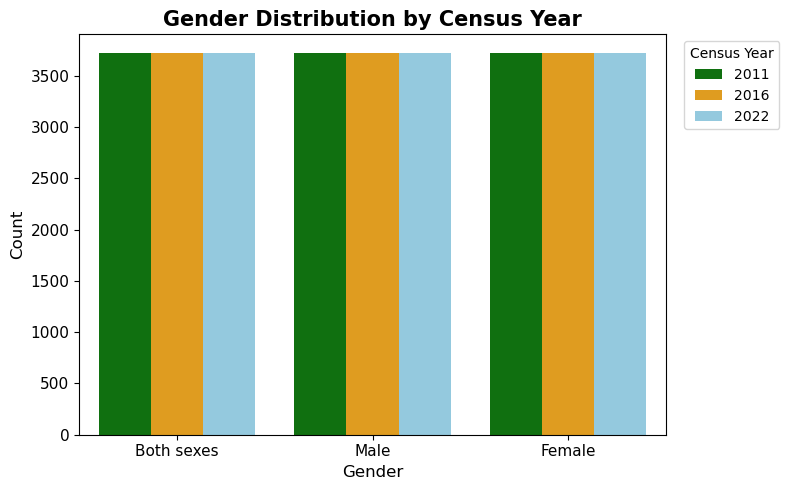

In [41]:
plt.figure(figsize=(8, 5))

palette_colors = {
    2011: 'green',
    2016: 'orange',
    2022: 'skyblue'}

sns.countplot(
    data=datapop_df,
    x='Gender',
    hue='CensusYear',
    palette=palette_colors,
    dodge=True)

plt.title('Gender Distribution by Census Year', fontsize=15, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title='Census Year', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()

### Population Distribution Across Area and Age Group

Scatter plots were used to examine the distribution of population values across geographic areas and age groups. This helps identify concentration patterns, extreme values, and aggregate demographic categories within the dataset.

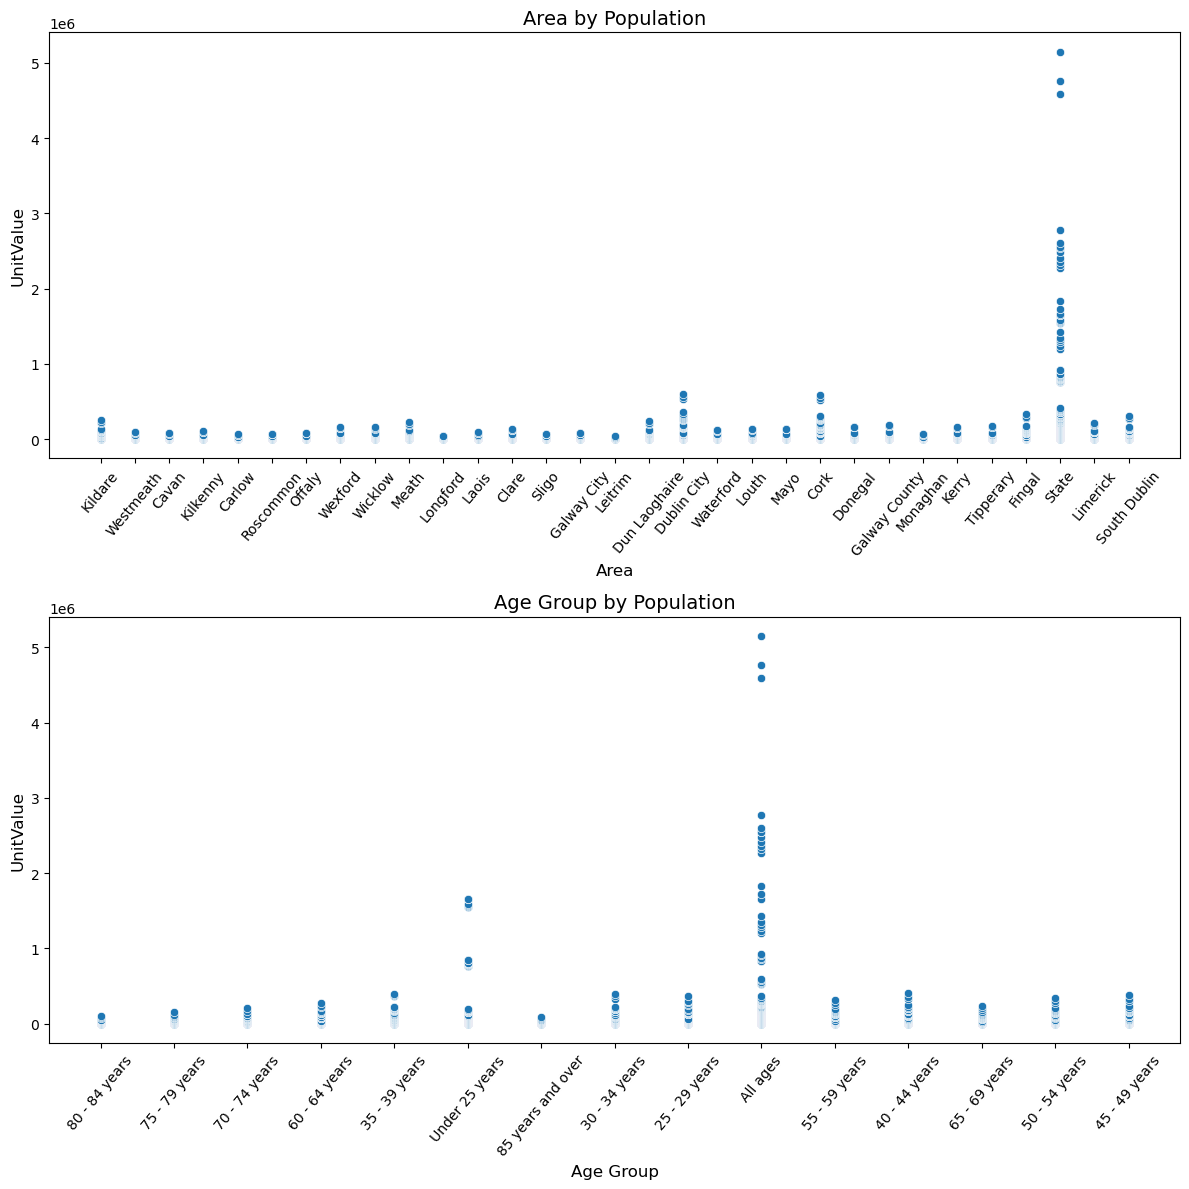

In [42]:
fig, axs = plt.subplots(2, 1, figsize=(12, 12))
sns.scatterplot(x='Area', y='UnitValue', data=datapop_df, ax=axs[0])
axs[0].set_title('Area by Population', fontsize=14)   
axs[0].set_xlabel('Area', fontsize=12)  
axs[0].set_ylabel('UnitValue', fontsize=12)
sns.scatterplot(x='AgeGroup', y='UnitValue', data=datapop_df, ax=axs[1])
axs[1].set_title('Age Group by Population', fontsize=14)   
axs[1].set_xlabel('Age Group', fontsize=12)  
axs[1].set_ylabel('UnitValue', fontsize=12) 
for ax in axs:
    ax.tick_params(axis='x', labelsize=10, rotation=50)  
    ax.tick_params(axis='y', labelsize=10) 
plt.tight_layout()
plt.show()

The visualisations show that the `State` area category and the `All ages` age group contain substantially larger population values than the remaining categories. These observations represent aggregated totals and may strongly influence the overall distribution of the dataset.

### Box Plot Analysis

Box plots were used to examine the distribution of population values across census years, marital status categories, and the target variable `UnitValue`. These visualisations help identify dispersion patterns, median values, and potential outliers within the dataset.

#### Population Distribution by Census Year

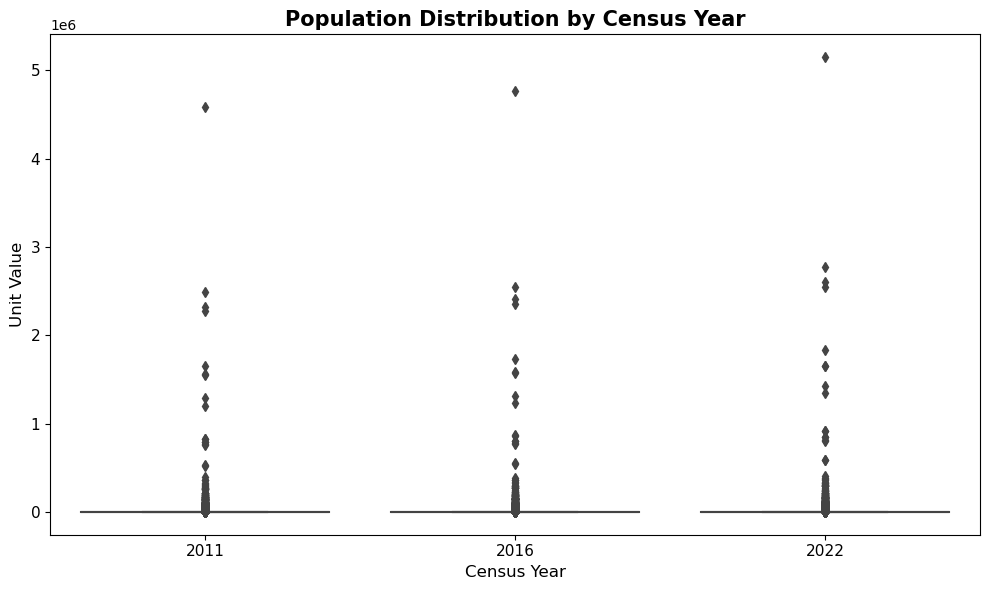

In [43]:
# Box plot: Census Year vs Population
plt.figure(figsize=(10,6))

sns.boxplot(
    x='CensusYear',
    y='UnitValue',
    data=datapop_df,
    palette='husl'
)

plt.title('Population Distribution by Census Year',
          fontsize=15,
          fontweight='bold')

plt.xlabel('Census Year', fontsize=12)
plt.ylabel('Unit Value', fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()

#### Population Distribution by Marital Status

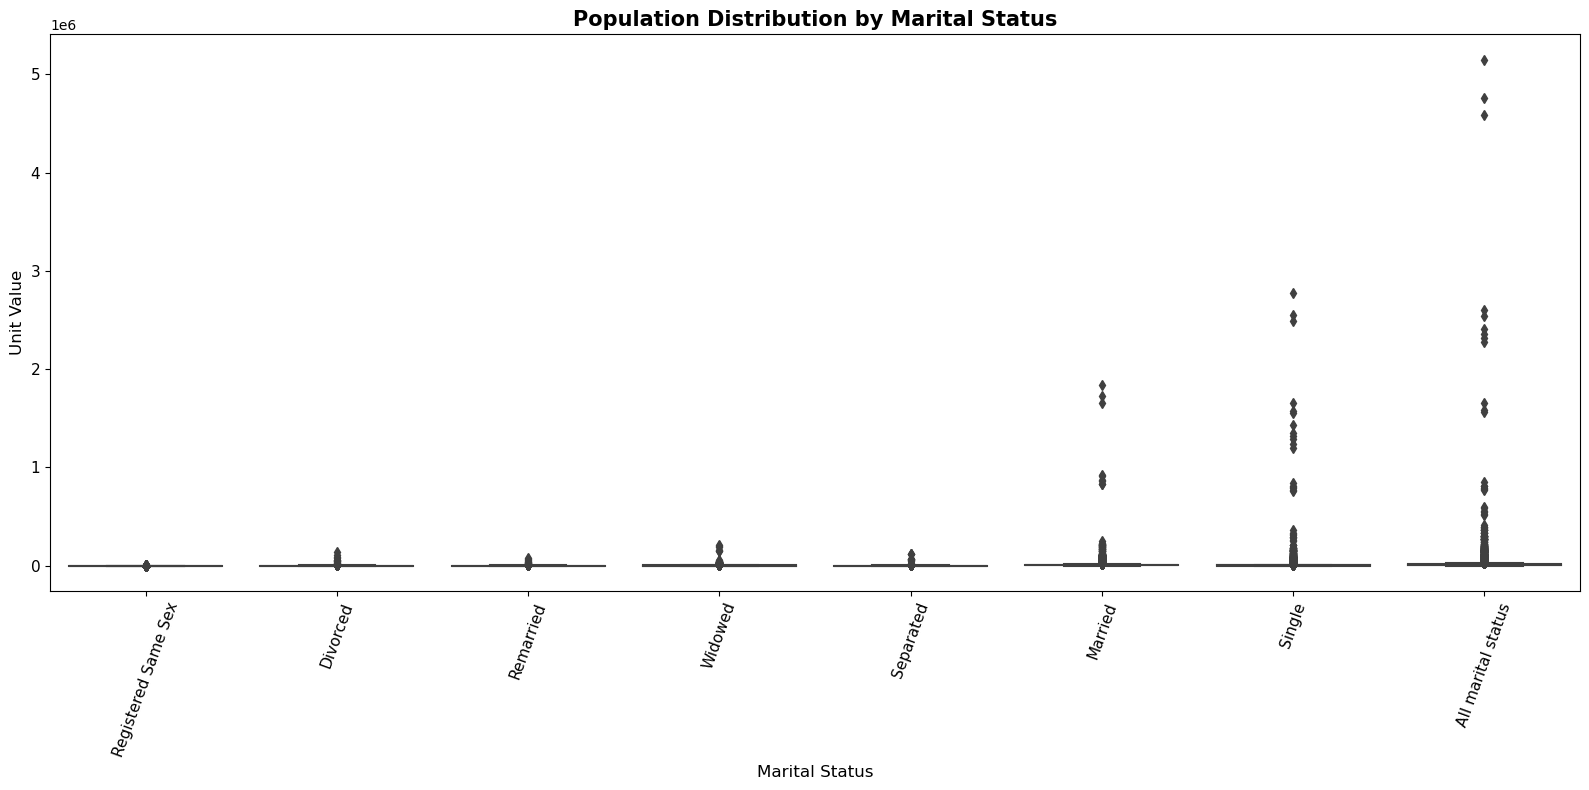

In [44]:
# Box plot: Marital Status vs Population
plt.figure(figsize=(16,8))

sns.boxplot(
    x='MaritalStatus',
    y='UnitValue',
    data=datapop_df,
    palette='husl'
)

plt.title('Population Distribution by Marital Status',
          fontsize=15,
          fontweight='bold')

plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Unit Value', fontsize=12)

plt.xticks(rotation=70, fontsize=11)
plt.yticks(fontsize=11)

plt.show()

#### Distribution of Unit Values

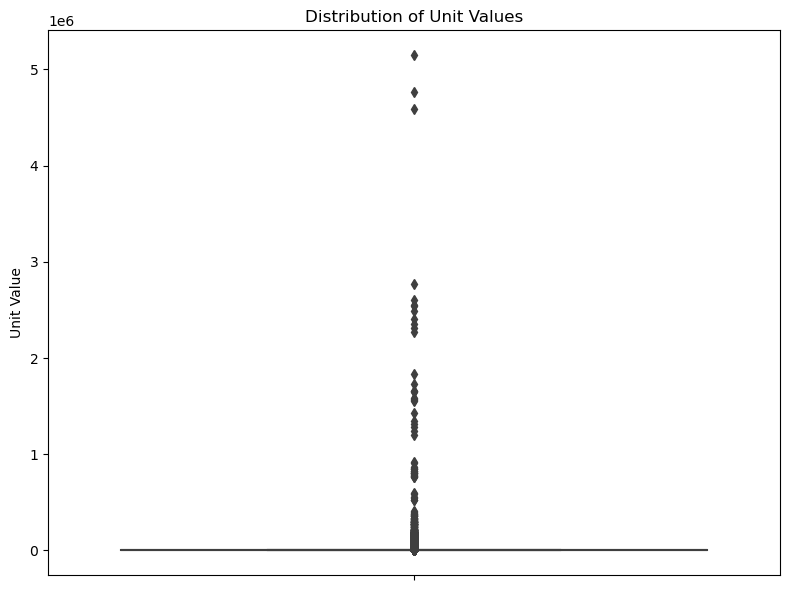

In [46]:
plt.figure(figsize=(8,6))

sns.boxplot(data=datapop_df, y='UnitValue')

plt.title('Distribution of Unit Values')
plt.ylabel('Unit Value')

plt.show()

The box plots reveal the presence of significant outliers and highly dispersed population values. These extreme observations are mainly associated with aggregated demographic categories and large regional population totals.

### Normal Distribution Visualisation

A simulated normal distribution was generated to illustrate the characteristics of symmetric data distributions, including central tendency, quartiles, and data spread.

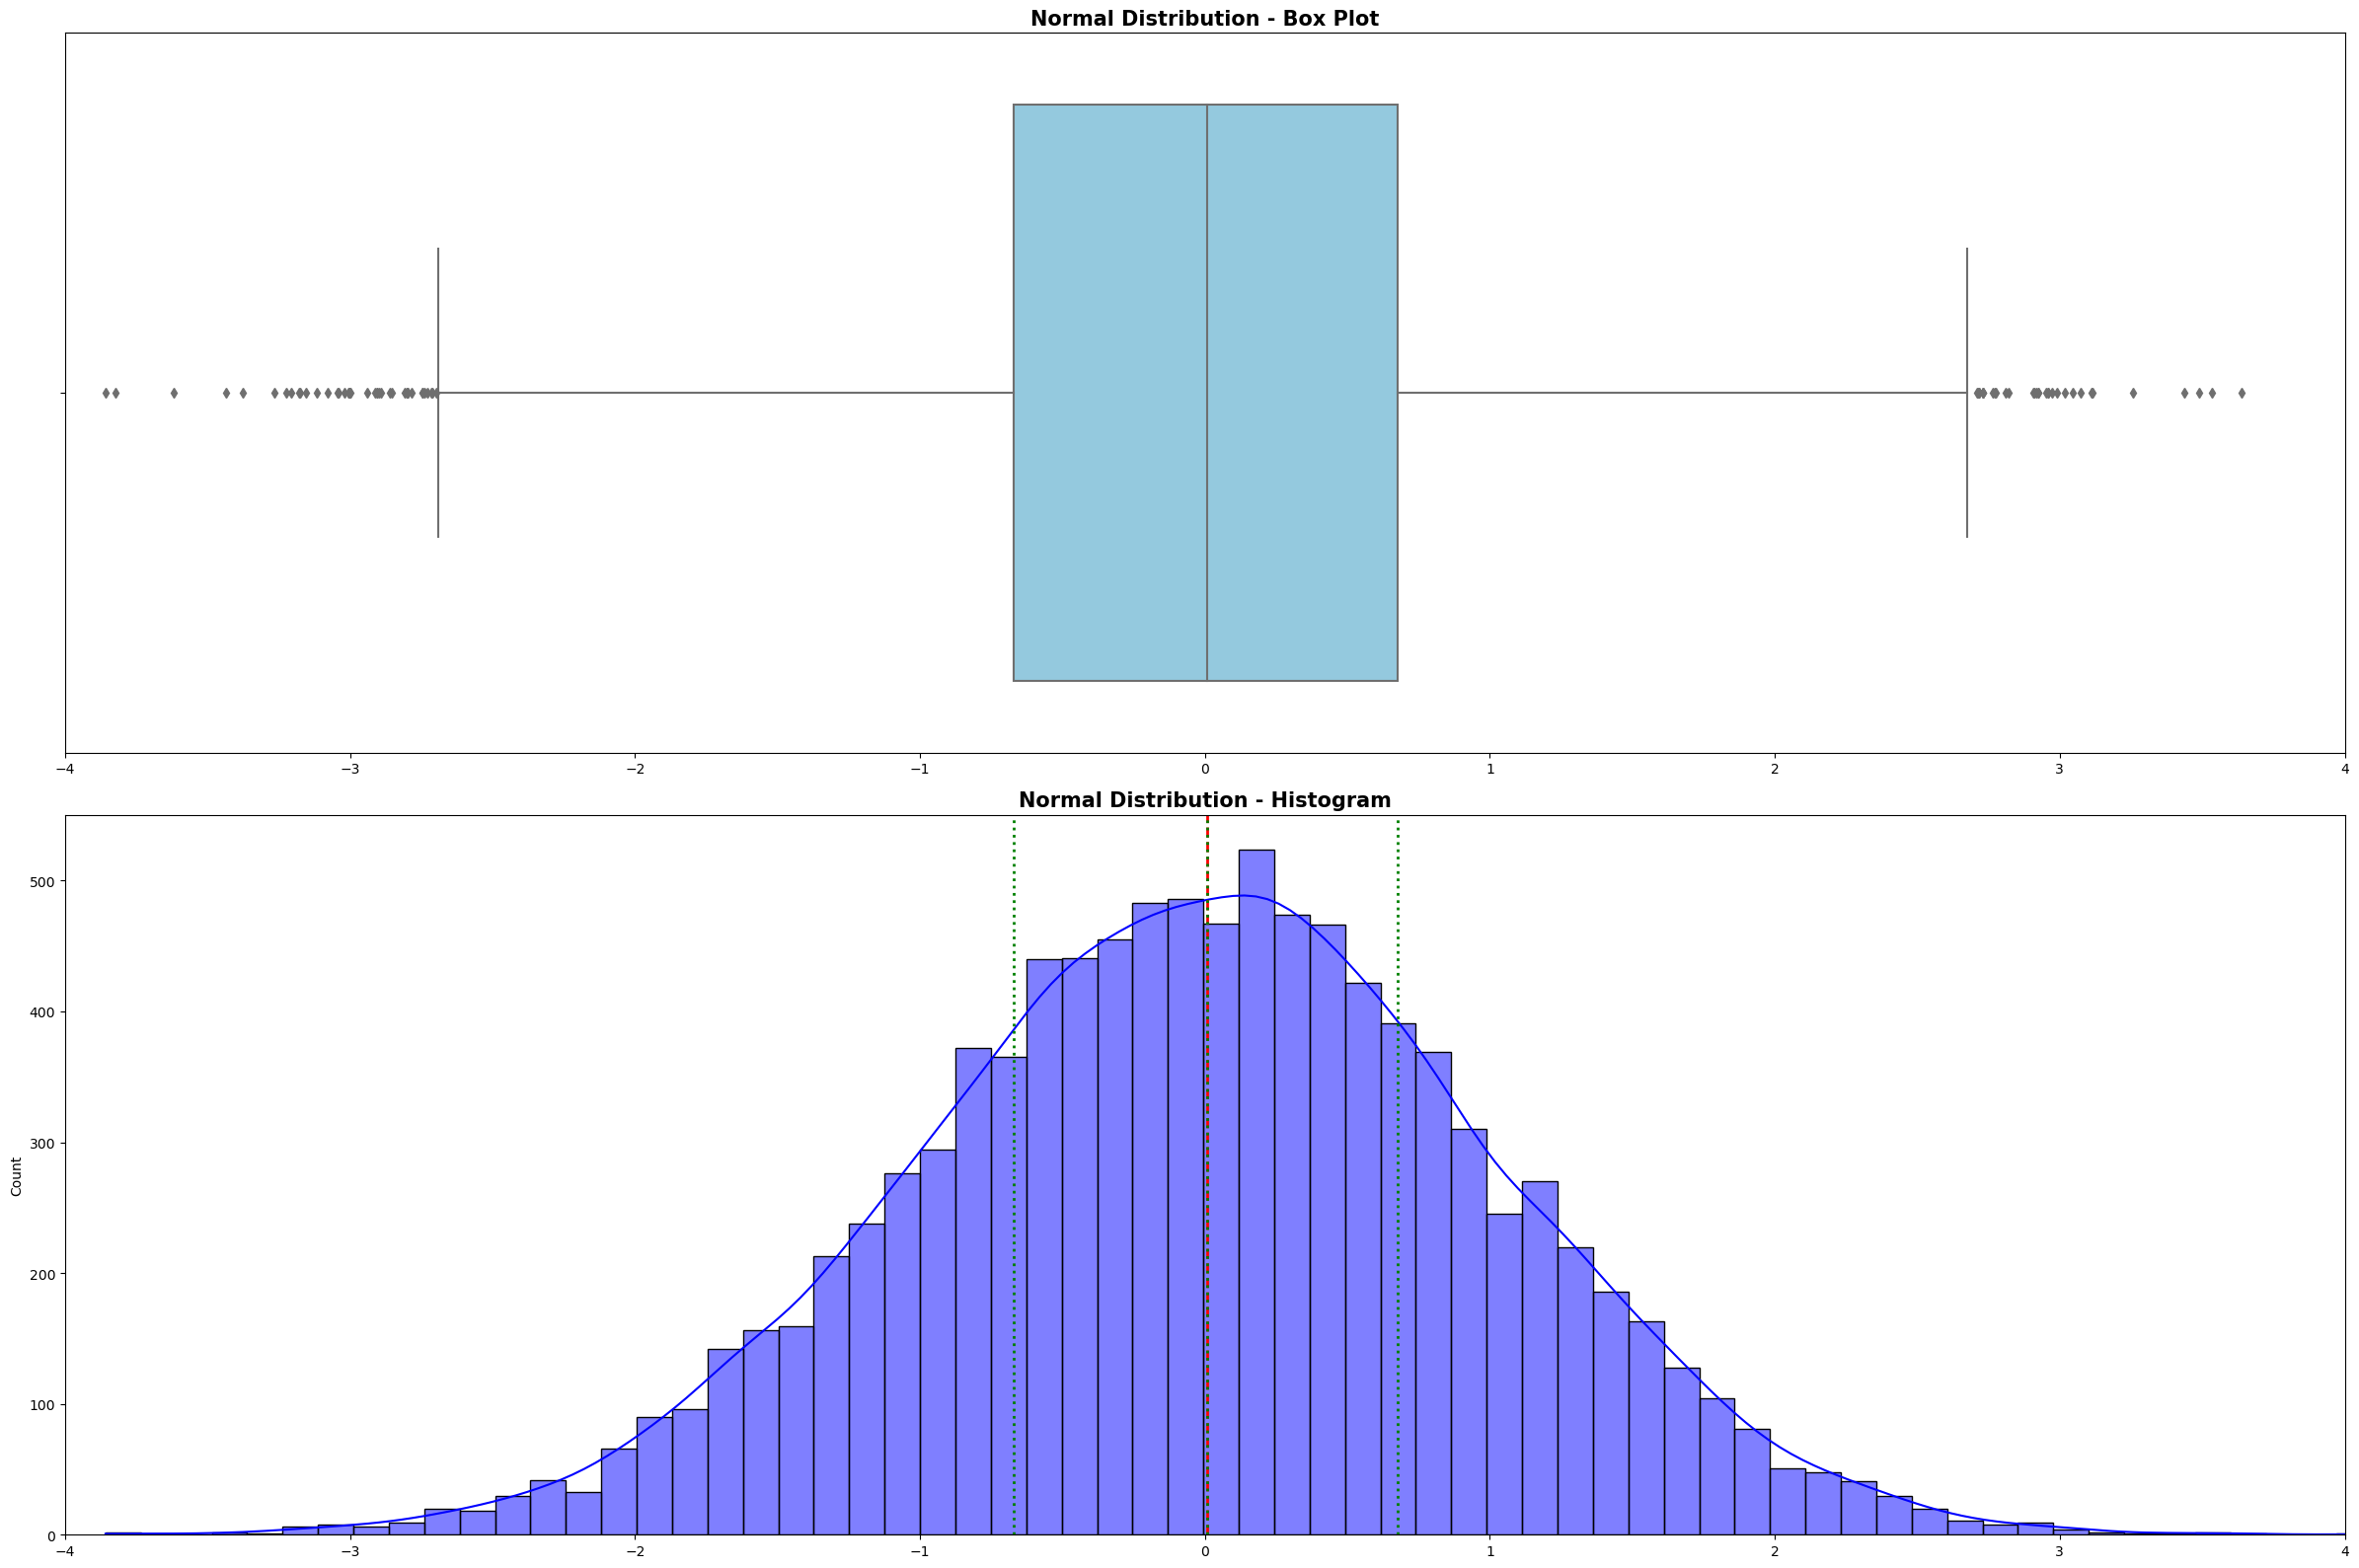

In [47]:
normal = np.random.normal(0, 1, 10000)

quartiles = pd.DataFrame(normal).quantile(
    [0.25, 0.5, 0.75, 1]
)[0]

fig, axs = plt.subplots(nrows=2, figsize=(24, 16))

# Box plot
sns.boxplot(
    x=normal,
    ax=axs[0],
    color='skyblue'
).set(xlim=(-4, 4))

axs[0].set_title(
    'Normal Distribution - Box Plot',
    fontsize=15,
    fontweight='bold'
)

# Histogram
sns.histplot(
    normal,
    kde=True,
    ax=axs[1],
    color='blue'
).set(xlim=(-4, 4))

axs[1].set_title(
    'Normal Distribution - Histogram',
    fontsize=15,
    fontweight='bold'
)

# Median line
plt.axvline(
    np.median(normal),
    color='red',
    linestyle='dashed',
    linewidth=2
)

# Quartile lines
for q in quartiles:
    plt.axvline(
        q,
        color='green',
        linestyle='dotted',
        linewidth=2
    )

plt.show()

The visualisation demonstrates the typical characteristics of a normal distribution, including symmetry around the median and a balanced spread of observations across quartiles.

### Removing Non-Informative Columns

Columns that did not contribute meaningful analytical value were removed to simplify the dataset and improve readability during analysis.

The columns `Statistic Label` and `UNIT` were removed because they contain constant values across all records and do not provide additional analytical information.

In [48]:
datapop_df.drop(columns=['Statistic Label', 'UNIT'],
                inplace=True,
                axis=1)

datapop_df.head(2)

,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UnitValue
14233,2016,Registered Same Sex,Kildare,Both sexes,80 - 84 years,0
14547,2016,Registered Same Sex,Westmeath,Both sexes,75 - 79 years,0


The dataset was updated in place to maintain a cleaner and more efficient structure for subsequent analysis and visualisation tasks.

### Removing Aggregate Records

Aggregate categories such as `All marital status`, `Both sexes`, `All ages`, and `State` were removed from the dataset to reduce duplication of total population counts and minimise the impact of extreme aggregate values on the analysis.

In [49]:
datapop_df.drop(datapop_df[datapop_df['MaritalStatus'] == 'All marital status'].index, inplace=True)
datapop_df.drop(datapop_df[datapop_df['Gender'] == 'Both sexes'].index, inplace=True)
datapop_df.drop(datapop_df[datapop_df['AgeGroup'] == 'All ages'].index, inplace=True)
datapop_df.drop(datapop_df[datapop_df['Area'] == 'State'].index, inplace=True)
datapop_df.head(10)

,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UnitValue
15238,2016,Registered Same Sex,Cavan,Male,80 - 84 years,0
3133,2011,Registered Same Sex,Kilkenny,Male,80 - 84 years,0
2869,2011,Registered Same Sex,Carlow,Female,35 - 39 years,0
9556,2011,Divorced,Roscommon,Male,Under 25 years,0
2864,2011,Registered Same Sex,Carlow,Male,85 years and over,0
2868,2011,Registered Same Sex,Carlow,Female,30 - 34 years,0
2867,2011,Registered Same Sex,Carlow,Female,25 - 29 years,0
2866,2011,Registered Same Sex,Carlow,Female,Under 25 years,0
14534,2016,Registered Same Sex,Offaly,Female,85 years and over,0
14533,2016,Registered Same Sex,Offaly,Female,80 - 84 years,0


The removal of aggregate records reduced the dataset size while preserving the detailed demographic observations required for analysis.

In [50]:
datapop_df.shape

(17640, 6)

### Distribution Analysis After Data Cleaning

A distribution plot was generated after removing aggregate columns and rows to evaluate the overall spread and behaviour of the remaining data.

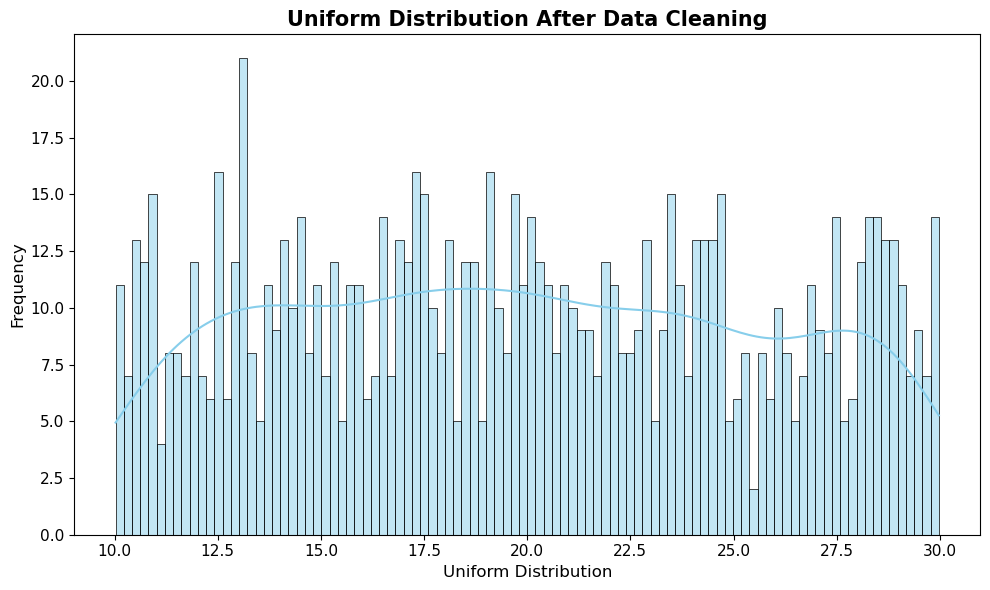

In [51]:
from scipy.stats import uniform

n = 1000
start = 10
width = 20

data_uniform = uniform.rvs(
    size=n,
    loc=start,
    scale=width
)

plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data_uniform,
    bins=100,
    kde=True,
    color='skyblue'
)

ax.set_xlabel('Uniform Distribution', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

plt.title(
    'Uniform Distribution After Data Cleaning',
    fontsize=15,
    fontweight='bold'
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()

The distribution appears relatively uniform after the removal of aggregate records, although some variability and outlier behaviour remain present within the dataset.

### Chi-Square Test for Categorical Variables

A Chi-Square test of independence was performed to evaluate the relationship between the categorical variables `Gender` and `MaritalStatus`.

In [52]:
from scipy.stats import chi2_contingency
crosstab = pd.crosstab(datapop_df['Gender'], datapop_df['MaritalStatus'])

In [53]:
chi2, p, dof, expected = chi2_contingency(crosstab)
print(f"Chi-Square Statistic: {chi2}, P-value: {p}")

Chi-Square Statistic: 0.0, P-value: 1.0


The Chi-Square test produced a statistic of 0.0 and a p-value of 1.0, indicating no statistically significant association between gender and marital status within the dataset. The observed frequencies closely match the expected frequencies under the null hypothesis of independence.

## Correlation Analysis of Numerical Variables

A correlation heatmap was generated to examine the relationships between the numerical variables in the dataset.

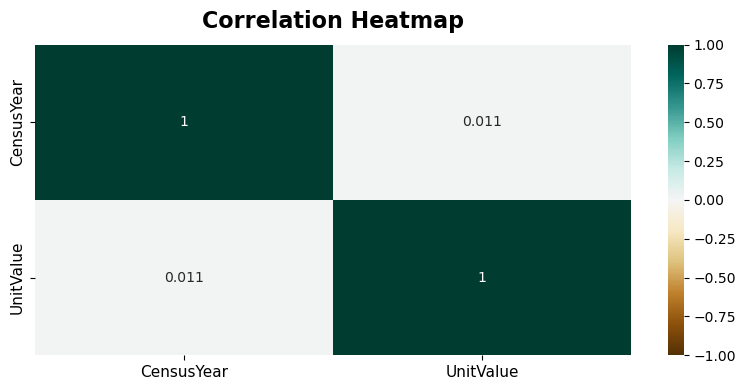

In [54]:
numeric_df = datapop_df.select_dtypes(include='number')

plt.figure(figsize=(8, 4))

heatmap = sns.heatmap(
    numeric_df.corr(),
    vmin=-1,
    vmax=1,
    annot=True,
    cmap='BrBG'
)

heatmap.set_title(
    'Correlation Heatmap',
    fontsize=16,
    fontweight='bold',
    pad=12
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

The heatmap shows a very weak positive correlation (`0.011`) between `CensusYear` and `UnitValue`, indicating that changes across census years have little linear relationship with population values in this dataset.

### Bernoulli Distribution Analysis

A Bernoulli distribution approach was applied to analyse the probability distribution of the binary gender variable across census years.

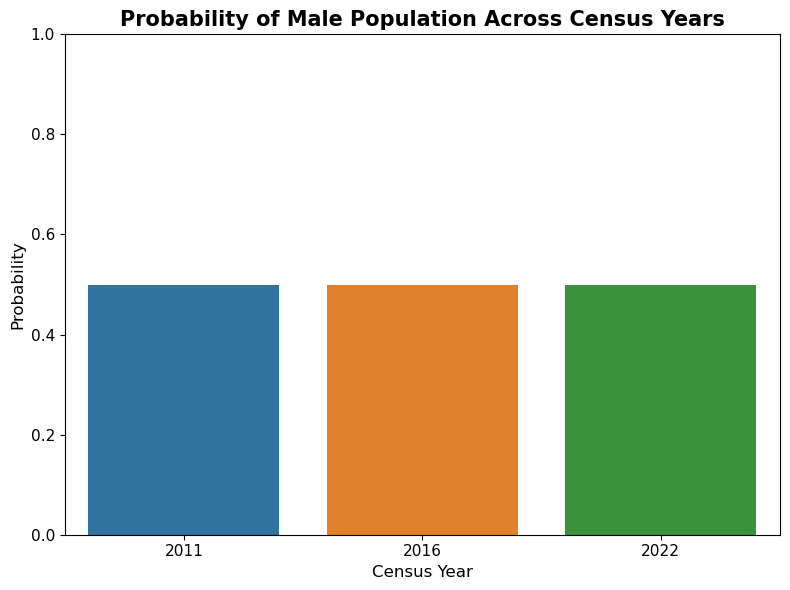

In [55]:
data_df = datapop_df.copy()

from scipy.stats import bernoulli

# Binary encoding for gender
data_df['GenderBinary'] = data_df['Gender'].apply(
    lambda x: 1 if x == 'Male' else 0
)

# Probability of male observations by census year
prob_male = data_df.groupby(
    'CensusYear'
)['GenderBinary'].mean()

prob_df = pd.DataFrame({
    'CensusYear': prob_male.index,
    'Probability': prob_male.values
})

# Visualisation
plt.figure(figsize=(8, 6))

sns.barplot(
    x='CensusYear',
    y='Probability',
    data=prob_df
)

plt.title(
    'Probability of Male Population Across Census Years',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Census Year', fontsize=12)
plt.ylabel('Probability', fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.ylim(0, 1)

plt.show()

The results indicate that the probability distribution of male observations remains close to 50% across all census years, reflecting the balanced gender structure within the dataset.

## Data Visualisation

### Population Trends Across Census Years

A bar chart was used to analyse population trends across the 2011, 2016, and 2022 census years.

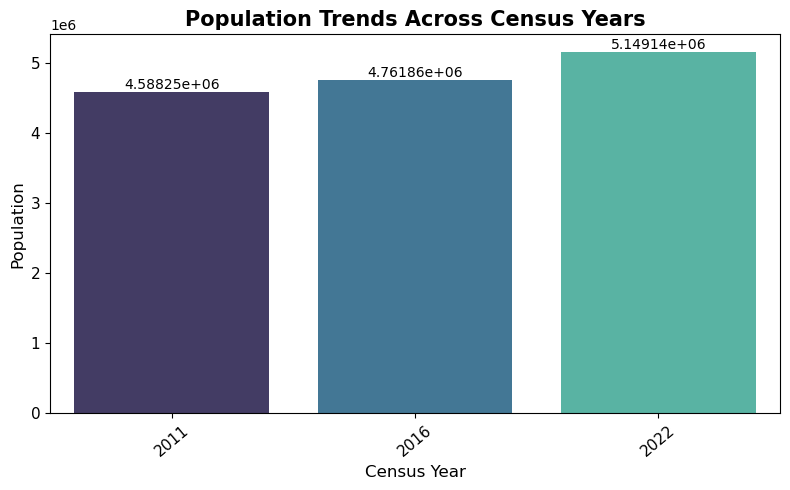

In [56]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=datapop_df,
    x='CensusYear',
    y='UnitValue',
    estimator='sum',
    palette='mako',
    errorbar=None
)

ax.bar_label(
    ax.containers[0],
    fontsize=10
)

plt.title(
    'Population Trends Across Census Years',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Census Year', fontsize=12)
plt.ylabel('Population', fontsize=12)

plt.xticks(rotation=40, fontsize=11)
plt.yticks(fontsize=11)

plt.show()

The visualisation shows a steady increase in Ireland’s population across the three census periods, with the highest population recorded in the 2022 census.

### Gender Distribution Across Census Years

A faceted bar chart was created to compare gender population distributions across the 2011, 2016, and 2022 census years.

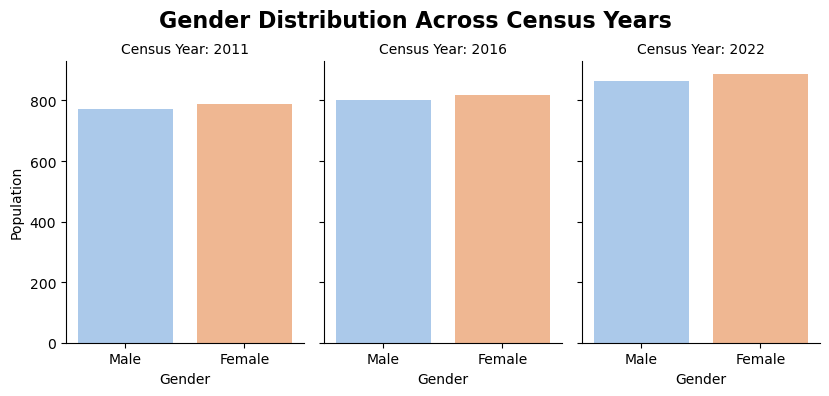

In [57]:
g = sns.catplot(
    data=datapop_df,
    kind='bar',
    x='Gender',
    y='UnitValue',
    col='CensusYear',
    height=4,
    aspect=.7,
    palette='pastel',
    errorbar=None
)

g.set_axis_labels('Gender', 'Population')

g.set_titles('Census Year: {col_name}')

g.fig.suptitle(
    'Gender Distribution Across Census Years',
    fontsize=16,
    fontweight='bold'
)

g.fig.subplots_adjust(top=0.85)

plt.show()

The visualisation suggests a slightly higher female population across the census years, although the overall gender distribution remains relatively balanced.

### Marital Status Distribution Analysis

The frequency and population totals of marital status categories were analysed to better understand demographic patterns within the dataset.

In [58]:
# To obtain the precise figures for every marital status
datapop_df['MaritalStatus'].value_counts()

MaritalStatus
Registered Same Sex    2520
Divorced               2520
Remarried              2520
Widowed                2520
Separated              2520
Married                2520
Single                 2520
Name: count, dtype: int64

The results show an equal number of observations across marital status categories due to the structured nature of the census dataset.

In [59]:
datapop_df[['UnitValue','MaritalStatus']].groupby('MaritalStatus').agg({'UnitValue': 'sum'})

,UnitValue
MaritalStatus,
Divorced,325085
Married,5216801
Registered Same Sex,7813
Remarried,188991
Separated,353824
Single,7809373
Widowed,597369


The `Single` and `Married` categories contain the highest population totals, while the `Registered Same Sex` category represents a considerably smaller proportion of the dataset.

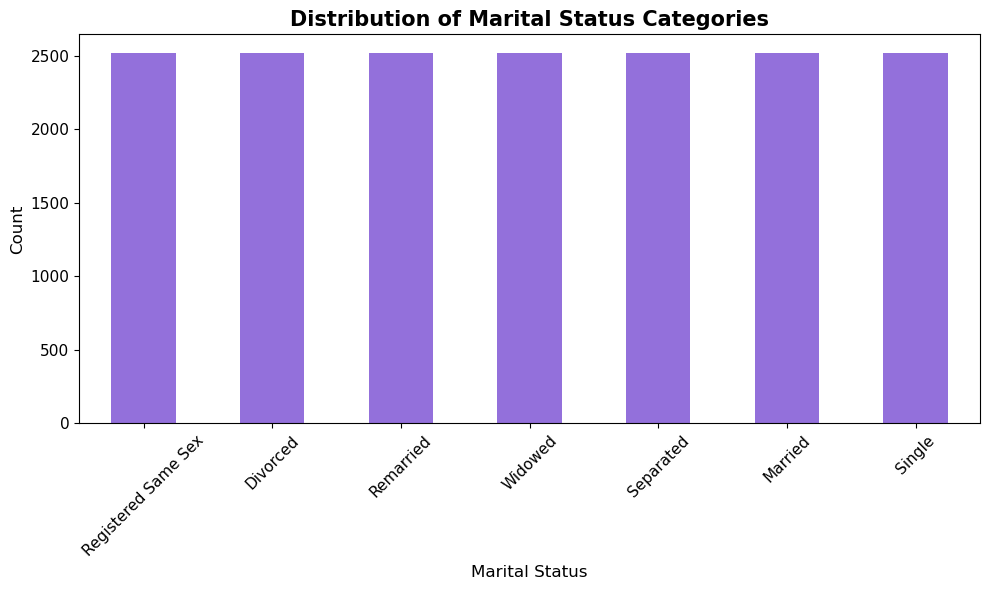

In [60]:
plt.figure(figsize=(10, 6))

datapop_df['MaritalStatus'] \
    .value_counts() \
    .plot.bar(color='mediumpurple')

plt.title(
    'Distribution of Marital Status Categories',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

plt.show()

The distribution of marital status categories is balanced across the dataset, with each category containing a similar number of observations.

### Distribution of Numerical Variables

Histograms were used to examine the distribution of numerical variables and identify general data patterns within the dataset.

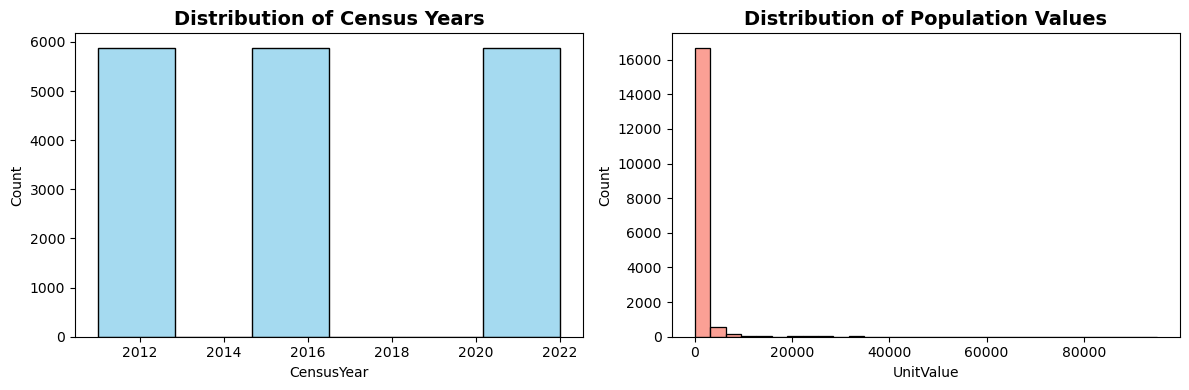

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    datapop_df['CensusYear'],
    bins=6,
    color='skyblue',
    ax=axes[0]
)

sns.histplot(
    datapop_df['UnitValue'],
    bins=30,
    color='salmon',
    ax=axes[1]
)

axes[0].set_title(
    'Distribution of Census Years',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_title(
    'Distribution of Population Values',
    fontsize=14,
    fontweight='bold'
)

for ax in axes:
    ax.grid(False)
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

The histograms show that `CensusYear` is evenly distributed across the three census periods, while `UnitValue` is highly right-skewed, indicating the presence of larger population outliers within the dataset.

### Population Distribution by Age Group

A bar chart was used to analyse population distribution across different age groups.

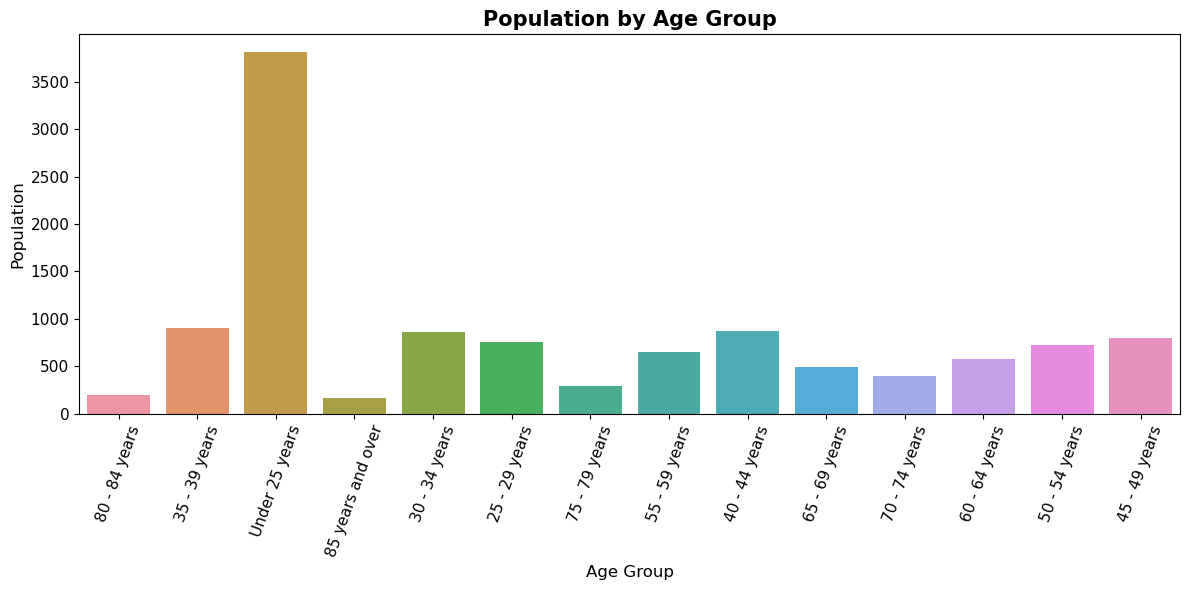

In [62]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=datapop_df,
    x='AgeGroup',
    y='UnitValue',
    errorbar=None
)

plt.title(
    'Population by Age Group',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Population', fontsize=12)

plt.xticks(rotation=70, fontsize=11)
plt.yticks(fontsize=11)

plt.show()

The visualisation indicates that younger age groups, particularly individuals under 25 years old, represent a substantial proportion of the population within the dataset.

Scatter and line plots were used to analyse population distribution and age group trends across census years.

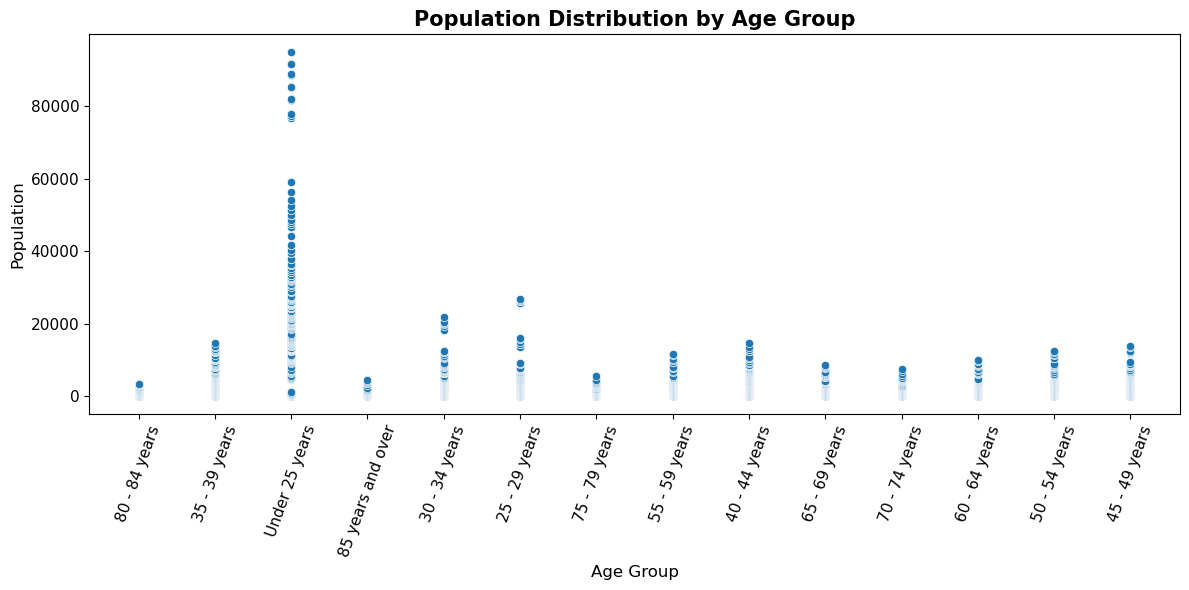

In [63]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=datapop_df,
    x='AgeGroup',
    y='UnitValue'
)

plt.title(
    'Population Distribution by Age Group',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Population', fontsize=12)

plt.xticks(rotation=70, fontsize=11)
plt.yticks(fontsize=11)

plt.grid(False)

plt.show()

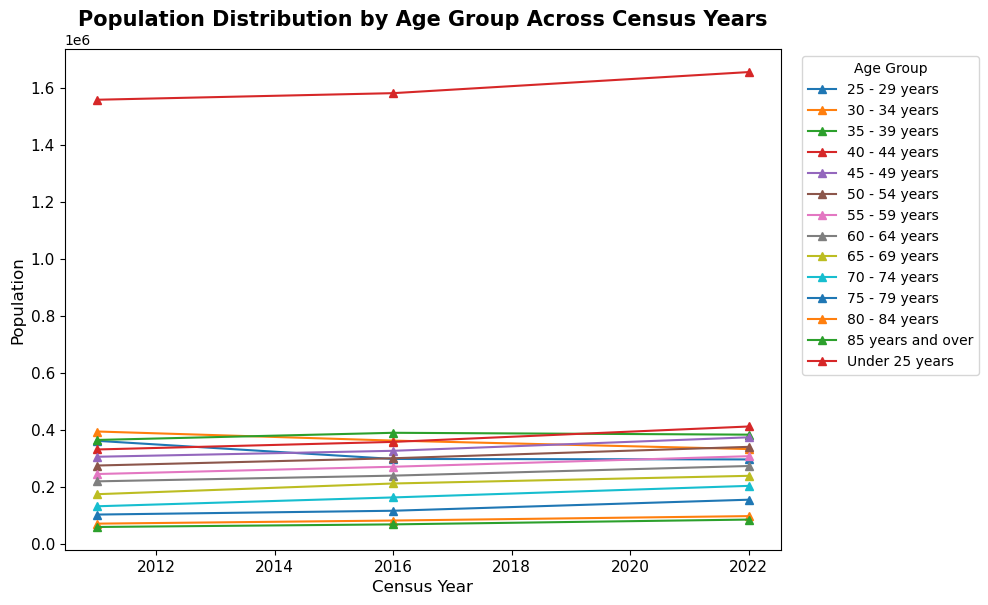

In [64]:
age_data = datapop_df[
    datapop_df['CensusYear'].isin([2011, 2016, 2022])
]

grouped_data = age_data.groupby(
    ['CensusYear', 'AgeGroup']
)['UnitValue'].sum().reset_index()

pivot_data = grouped_data.pivot(
    index='CensusYear',
    columns='AgeGroup',
    values='UnitValue'
)

pivot_data.plot(
    kind='line',
    marker='^',
    figsize=(10, 6)
)

plt.title(
    'Population Distribution by Age Group Across Census Years',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Census Year', fontsize=12)
plt.ylabel('Population', fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(
    title='Age Group',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(False)

plt.show()

The visualisations show noticeable differences in population distribution across age groups, with younger age categories representing a larger proportion of the population throughout the census years.

### Population Trend for the 85+ Age Group

A line chart was used to analyse population trends for individuals aged 85 years and over across the 2011, 2016, and 2022 census periods.

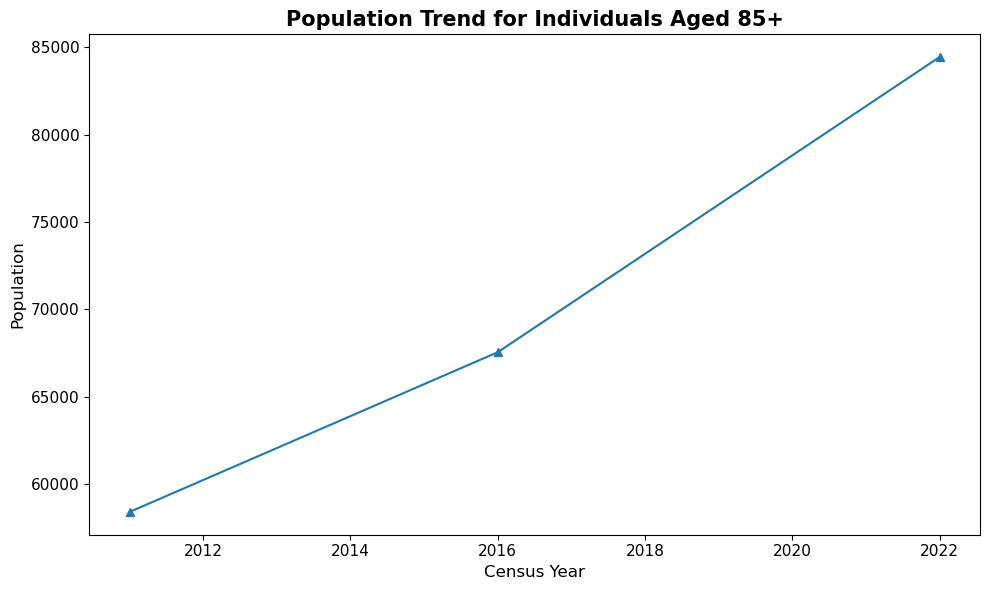

In [65]:
age_data = datapop_df[
    (datapop_df['AgeGroup'] == '85 years and over') &
    (datapop_df['CensusYear'].isin([2011, 2016, 2022]))
]

grouped_data = age_data.groupby(
    'CensusYear'
)['UnitValue'].sum()

grouped_data.plot(
    kind='line',
    marker='^',
    figsize=(10, 6)
)

plt.title(
    'Population Trend for Individuals Aged 85+',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Census Year', fontsize=12)
plt.ylabel('Population', fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(False)

plt.show()

The results show a consistent increase in the population aged 85 years and over across the census periods, indicating an ageing population trend in Ireland.

#### Population Comparison by Census Year and Gender

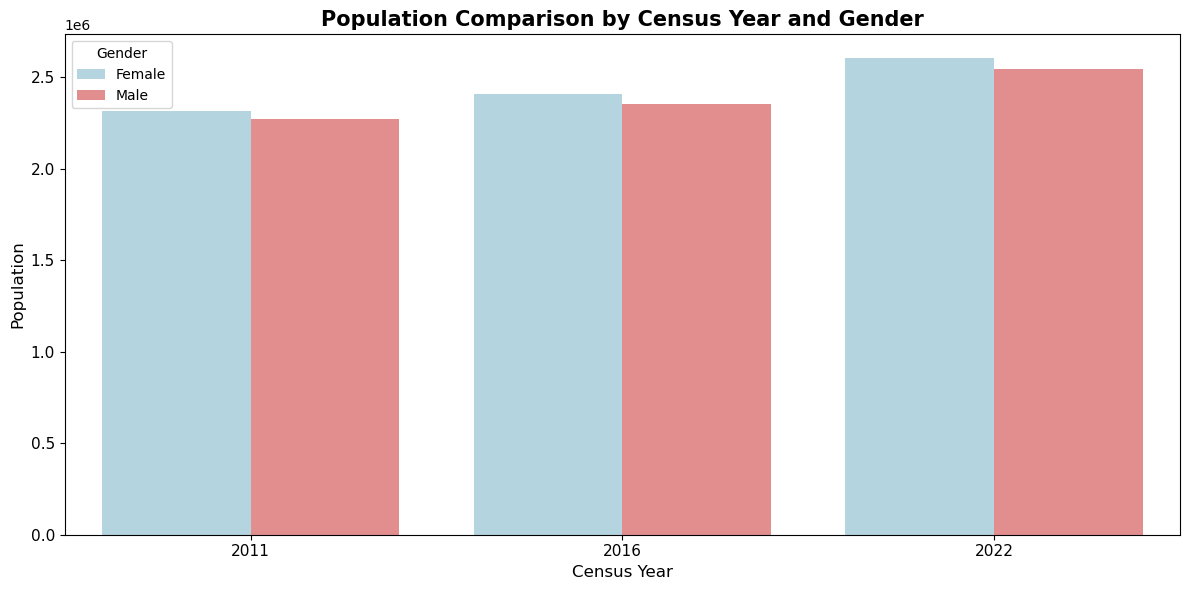

In [66]:
gender_data = datapop_df.groupby(
    ['CensusYear', 'Gender']
)['UnitValue'].sum().reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=gender_data,
    x='CensusYear',
    y='UnitValue',
    hue='Gender',
    palette=['lightblue', 'lightcoral'],
    errorbar=None
)

plt.title(
    'Population Comparison by Census Year and Gender',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Census Year', fontsize=12)
plt.ylabel('Population', fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(title='Gender')

plt.grid(False)

plt.show()

The visualisation indicates a relatively balanced population distribution between males and females across all census years, with females showing slightly higher population totals.

#### Distribution of Marital Status and Age Group

Histograms were used to analyse the distribution patterns of marital status and age group categories within the dataset.

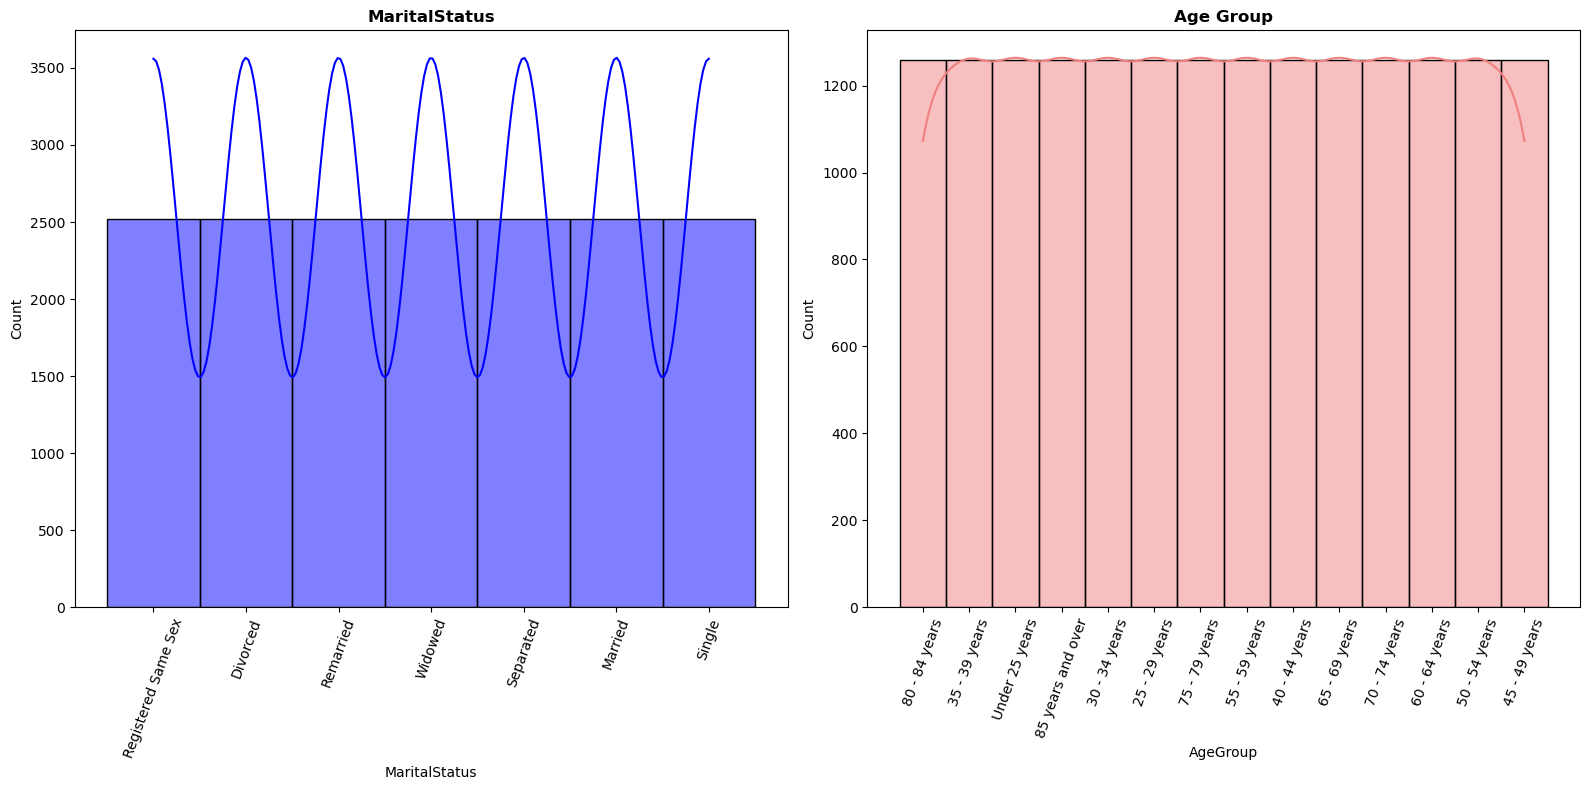

In [67]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

sns.histplot(data=datapop_df, x='MaritalStatus', kde=True, color='blue', ax=axs[0])
axs[0].set_title('MaritalStatus', fontsize=12, weight='bold')
axs[0].tick_params(axis='x', rotation=70)  

sns.histplot(data=datapop_df, x='AgeGroup', kde=True, color='lightcoral', ax=axs[1], bins=25)
axs[1].set_title('Age Group', fontsize=12, weight='bold') 
axs[1].tick_params(axis='x', rotation=70)

plt.tight_layout()
plt.show()

The visualisations show relatively balanced distributions across marital status categories, while age groups display greater variation in population counts.

#### Population Distribution by Area

A bar chart was used to analyse population distribution across Irish areas during the intercensal periods of 2011, 2016, and 2022.

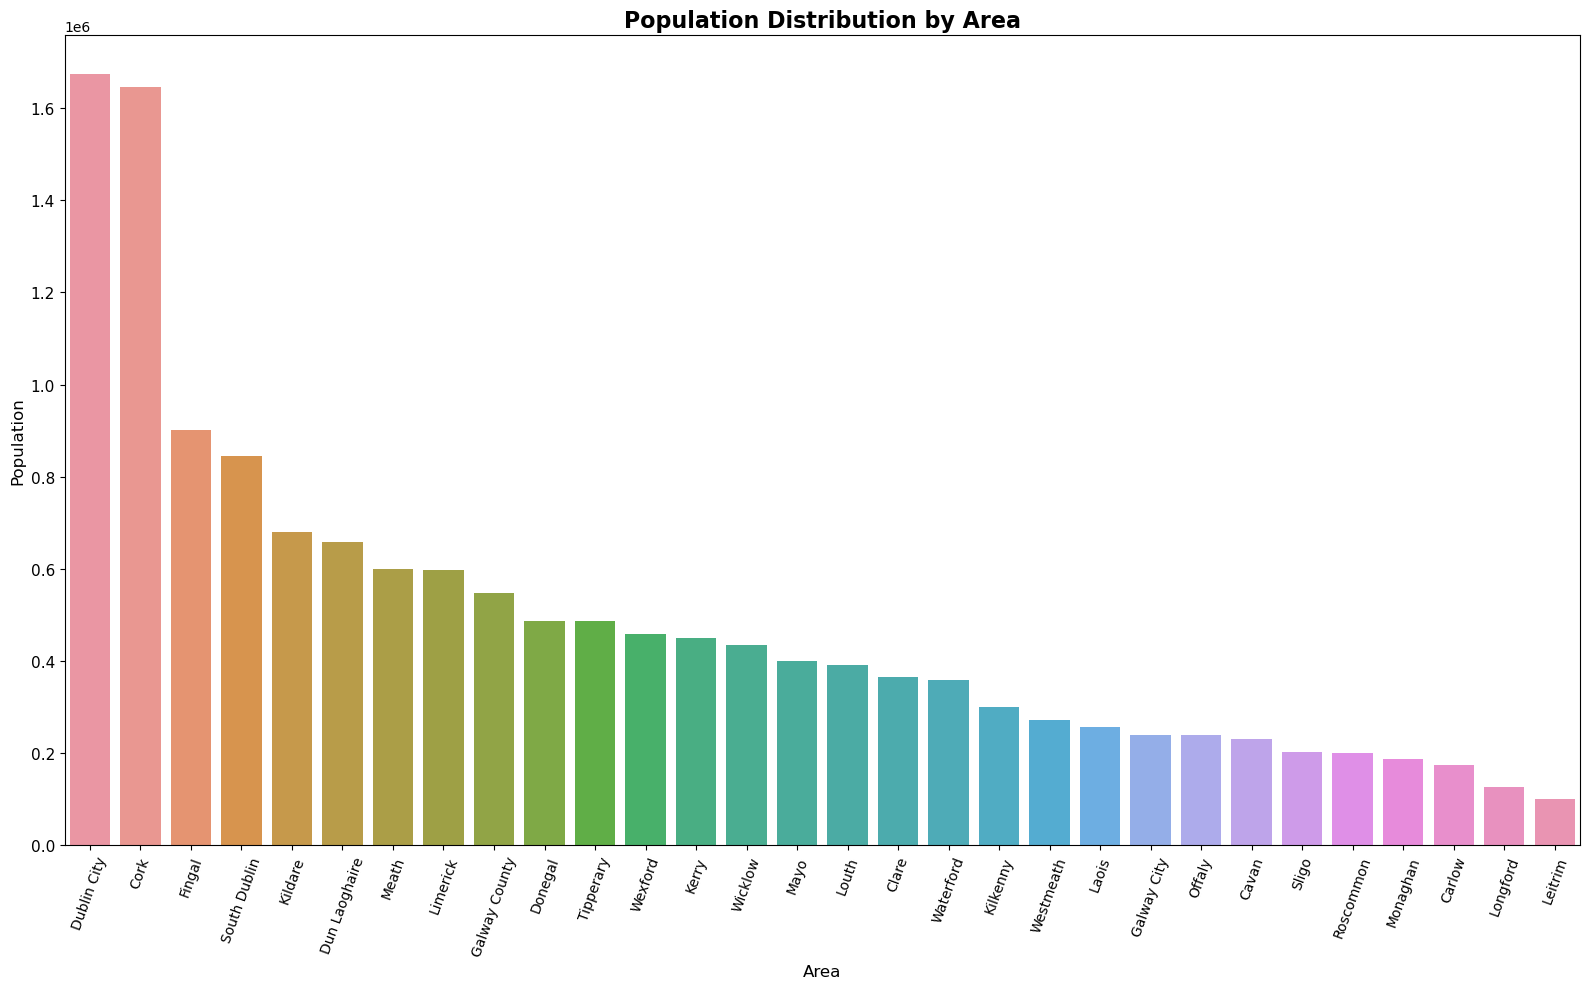

In [68]:
sorted_df = datapop_df.groupby(
    'Area'
)['UnitValue'].sum().reset_index()

sorted_df = sorted_df.sort_values(
    'UnitValue',
    ascending=False
)

plt.figure(figsize=(16, 10))

sns.barplot(
    data=sorted_df,
    x='Area',
    y='UnitValue',
    errorbar=None
)

plt.title(
    'Population Distribution by Area',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Area', fontsize=12)
plt.ylabel('Population', fontsize=12)

plt.xticks(rotation=70, fontsize=10)
plt.yticks(fontsize=11)

plt.grid(False)

plt.show()

The visualisation indicates that Dublin and Cork represent the most populous areas within the dataset.

#### Top 10 Most Populated Areas

A bar chart was created to identify the ten areas with the highest population totals across the intercensal periods.

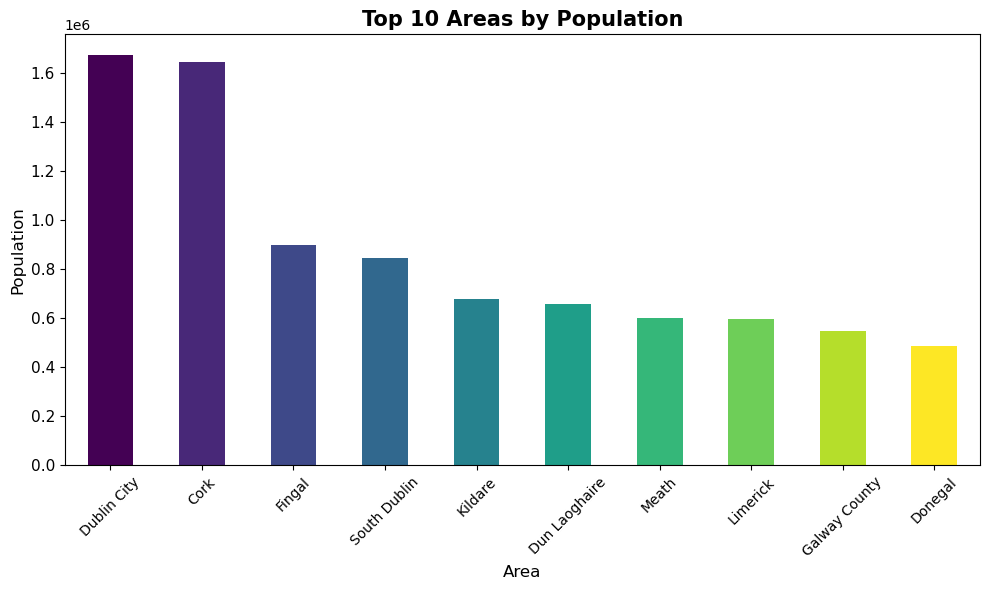

In [69]:
# Top 10 areas by population
top_10 = datapop_df.groupby(
    'Area'
)['UnitValue'].sum().nlargest(10)

plt.figure(figsize=(10, 6))

top_10.plot(
    kind='bar',
    color=cm.viridis(
        np.linspace(0, 1, len(top_10))
    )
)

plt.title(
    'Top 10 Areas by Population',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Area', fontsize=12)
plt.ylabel('Population', fontsize=12)

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=11)

plt.grid(False)

plt.show()

The visualisation highlights Dublin and Cork as the areas with the highest population totals, indicating strong population concentration within these regions.

#### Population Totals by Census Year

Population totals were aggregated to compare demographic growth across the 2011, 2016, and 2022 census periods.

In [70]:
value_CensusYear = datapop_df

In [71]:
value_censusyear = datapop_df.groupby('CensusYear')[['UnitValue']].sum()
print(value_censusyear.sort_values(by = ['UnitValue']))

            UnitValue
CensusYear           
2011          4588252
2016          4761865
2022          5149139


The aggregated results indicate consistent population growth across all census periods.

#### Population Distribution by Area

A line plot was used to visualise population distribution across Irish areas.

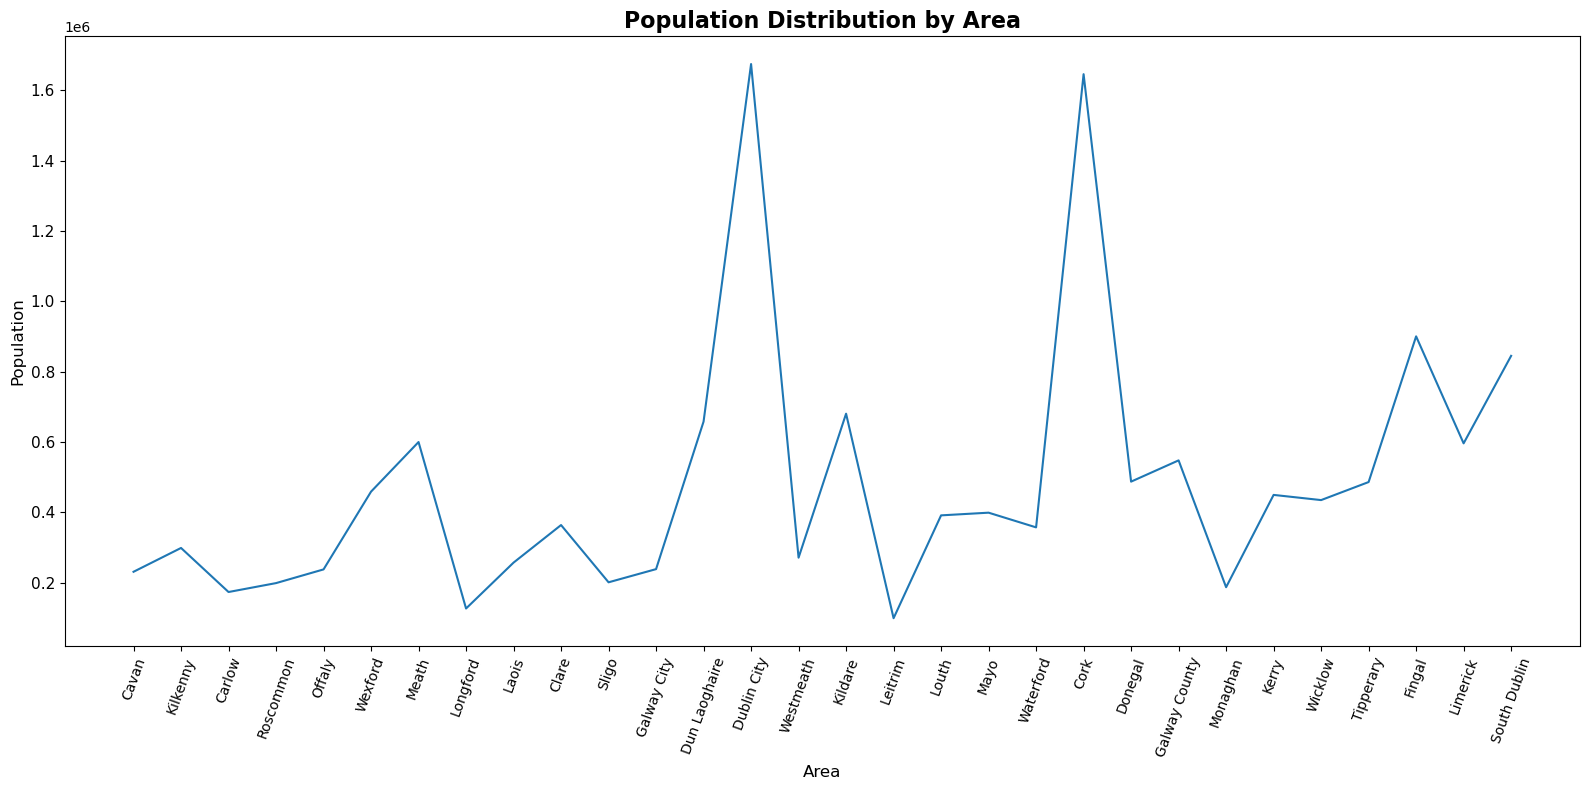

In [72]:
plt.figure(figsize=(16, 8))

sns.lineplot(
    data=datapop_df,
    x='Area',
    y='UnitValue',
    estimator='sum',
    errorbar=None
)

plt.title(
    'Population Distribution by Area',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Area', fontsize=12)
plt.ylabel('Population', fontsize=12)

plt.xticks(rotation=70, fontsize=10)
plt.yticks(fontsize=11)

plt.grid(False)

plt.show()

The visualisation highlights Dublin and Cork as the areas with the highest population totals within the dataset.

## Feature Engineering

### Separating Numerical and Categorical Variables

The dataset contains both numerical and categorical variables. Categorical features were identified to prepare the dataset for encoding and further analysis.

In [73]:
cat_cols = datapop_df.select_dtypes(
    include=['object']
).columns

num_cols = datapop_df.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical Variables:")
print(cat_cols)

print("\nNumerical Variables:")
print(num_cols)

Categorical Variables:
Index(['MaritalStatus', 'Area', 'Gender', 'AgeGroup'], dtype='object')

Numerical Variables:
['CensusYear', 'UnitValue']


The identified categorical variables were later transformed into numerical representations using encoding techniques suitable for machine learning workflows.

### Label Encoding

Label Encoding was applied to the `AgeGroup` variable because it contains categories with a natural ordinal relationship. This process converts categorical values into numerical representations suitable for machine learning algorithms.

### Creating a Working Dataset Copy

In [74]:
new_data = datapop_df

A copy of the dataset was created to preserve the original data during the feature engineering process.

#### Encoding the `AgeGroup` Variable

The `AgeGroup` feature was transformed into numerical values using Label Encoding to preserve the ordinal relationship between age categories.

In [75]:
from sklearn.preprocessing import LabelEncoder

le_encoder = LabelEncoder()

new_data['AgeGroup'] = le_encoder.fit_transform(
    new_data['AgeGroup']
)

unique_sorted_values = sorted(
    new_data['AgeGroup'].unique()
)

mapping = dict(
    zip(
        unique_sorted_values,
        range(len(unique_sorted_values))
    )
)

print('Encoding Mapping:')

Encoding Mapping:


The encoding mapping was displayed to verify that each age category was correctly transformed into a numerical value.

In [76]:
for key, value in mapping.items():
    print(f'{key} was encoded as {value}')

0 was encoded as 0
1 was encoded as 1
2 was encoded as 2
3 was encoded as 3
4 was encoded as 4
5 was encoded as 5
6 was encoded as 6
7 was encoded as 7
8 was encoded as 8
9 was encoded as 9
10 was encoded as 10
11 was encoded as 11
12 was encoded as 12
13 was encoded as 13


The encoded values now allow the `AgeGroup` feature to be used in statistical analysis and machine learning models.

#### Encoded Dataset Preview

In [77]:
new_data.head(2)

,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UnitValue
15238,2016,Registered Same Sex,Cavan,Male,11,0
3133,2011,Registered Same Sex,Kilkenny,Male,11,0


The `AgeGroup` column now contains encoded numerical values, making the feature suitable for statistical analysis and machine learning applications.

### Gender Variable Encoding

The `Gender` variable was transformed into numerical values to make the feature compatible with statistical analysis and machine learning models.

In [78]:
# Mapping gender categories to numerical values
dict_Gender = {
    'Male': 1,
    'Female': 2
}

new_data['Gender'] = new_data['Gender'].map(
    dict_Gender
)

# Preview updated dataset
new_data.head(2)

,CensusYear,MaritalStatus,Area,Gender,AgeGroup,UnitValue
15238,2016,Registered Same Sex,Cavan,1,11,0
3133,2011,Registered Same Sex,Kilkenny,1,11,0


The categorical gender labels were successfully converted into numerical representations while preserving the original class distinctions.

In [79]:
new_data.Gender.unique()

array([1, 2], dtype=int64)

In [80]:
new_data[['UnitValue','Gender']].groupby('Gender').agg({'UnitValue': 'sum'})

,UnitValue
Gender,
1,7171676
2,7327580


### One-Hot Encoding

One-Hot Encoding was applied to the `MaritalStatus` and `Area` variables to convert categorical features into machine learning-compatible numerical representations.

This encoding technique creates binary indicator columns for each category while avoiding the introduction of ordinal relationships between categorical variables.

In [81]:
#pip install category_encoders

In [82]:
# Import encoding library
import category_encoders as ce

# Variables to encode
columns_to_encode = [
    'MaritalStatus',
    'Area'
]

# Apply One-Hot Encoding
encoder = ce.OneHotEncoder(
    cols=columns_to_encode
)

new_data = encoder.fit_transform(
    datapop_df
)

# Preview transformed dataset
new_data.head(2)

,CensusYear,MaritalStatus_1,MaritalStatus_2,MaritalStatus_3,MaritalStatus_4,MaritalStatus_5,MaritalStatus_6,MaritalStatus_7,Area_1,Area_2,Area_3,Area_4,Area_5,Area_6,Area_7,Area_8,Area_9,Area_10,Area_11,Area_12,Area_13,Area_14,Area_15,Area_16,Area_17,Area_18,Area_19,Area_20,Area_21,Area_22,Area_23,Area_24,Area_25,Area_26,Area_27,Area_28,Area_29,Area_30,Gender,AgeGroup,UnitValue
15238,2016,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,11,0
3133,2011,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,11,0


The encoded dataset now contains binary indicator variables representing each category within the `MaritalStatus` and `Area` features.

In [83]:
new_data.shape

(17640, 41)

The dataset increased from 6 to 41 columns after encoding, reflecting the creation of additional binary features for categorical variables.

In [84]:
# Summary statistics of the transformed dataset
new_data.describe()

,CensusYear,MaritalStatus_1,MaritalStatus_2,MaritalStatus_3,MaritalStatus_4,MaritalStatus_5,MaritalStatus_6,MaritalStatus_7,Area_1,Area_2,Area_3,Area_4,Area_5,Area_6,Area_7,Area_8,Area_9,Area_10,Area_11,Area_12,Area_13,Area_14,Area_15,Area_16,Area_17,Area_18,Area_19,Area_20,Area_21,Area_22,Area_23,Area_24,Area_25,Area_26,Area_27,Area_28,Area_29,Area_30,Gender,AgeGroup,UnitValue
count,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000,17640.000000
mean,2016.333333,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,1.500000,6.500000,821.953288
std,4.497040,0.349937,0.349937,0.349937,0.349937,0.349937,0.349937,0.349937,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.179511,0.500014,4.031243,3561.861167
min,2011.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,2011.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,10.000000
50%,2016.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,6.500000,97.000000
75%,2022.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,10.000000,389.000000
max,2022.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,13.000000,95005.000000


The summary statistics confirm that the categorical variables were successfully transformed into numerical features suitable for machine learning analysis.

The One-Hot Encoded variables contain binary values (`0` and `1`), while the `Gender` and `AgeGroup` variables are now represented numerically.

In [85]:
print(new_data['Gender'].dtype)  
print(new_data['Gender'].value_counts())

int64
Gender
1    8820
2    8820
Name: count, dtype: int64


The `Gender` variable was successfully converted to an integer (`int64`) data type, with balanced distributions between the encoded male (`1`) and female (`2`) categories.

## Machine Learning Modelling and Evaluation

### Modelling Approach

The following steps were applied during the machine learning preparation stage:

- Split the dataset into training and testing sets.
- Standardise the training data.
- Apply the same transformation parameters to the testing data.

Standardisation was performed after splitting the dataset to prevent data leakage and ensure reliable model evaluation.

The `UnitValue` and `AgeGroup` variables contain substantially different numerical ranges. Standardisation helps improve model performance by scaling the variables to a comparable range.

## Logistic Regression Model

The `Gender` variable was selected as the target variable (`y`), while all remaining variables were used as predictor features (`X`).

In [95]:
from sklearn.model_selection import train_test_split

# Creating feature matrix and target variable
X = new_data.drop(
    'Gender',
    axis=1
)

y = new_data['Gender']

The dataset was divided into training and testing subsets using a 70:30 ratio. The training set is used to train the model, while the testing set evaluates model performance on unseen data.

In [96]:
# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

## Feature Scaling

Feature scaling was applied using standardisation to ensure that all numerical variables contributed equally to the machine learning model.

Standardisation transforms the data to a common scale with a mean close to 0 and a standard deviation close to 1, helping improve model stability and performance.

In [97]:
# Standardising the training and testing data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression Training

In [98]:
from sklearn.linear_model import LogisticRegression

# Creating and training the Logistic Regression model
log_reg = LogisticRegression()

log_reg.fit(X_train, y_train)

LogisticRegression()

The Logistic Regression model was trained using the standardised training dataset to classify the target variable (`Gender`).

In [99]:
# Predicting values on the test set
y_pred = log_reg.predict(X_test)

### Model Evaluation

In [100]:
# Evaluating model accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy}')

Accuracy: 0.47732426303854875


The model achieved an accuracy score of approximately `47%`, indicating relatively weak predictive performance on unseen data.

In [101]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Training accuracy
print(
    accuracy_score(
        y_train,
        log_reg.predict(X_train)
    )
)

0.5095562034337544


In [102]:
# Testing accuracy
log_reg_acc = accuracy_score(
    y_test,
    log_reg.predict(X_test)
)

print(log_reg_acc)

0.47732426303854875


The training and testing accuracy scores are relatively similar, suggesting that the model is not significantly overfitting the dataset.

In [103]:
# Confusion matrix
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

[[1212 1467]
 [1299 1314]]


The confusion matrix summarises the classification performance by showing the number of correctly and incorrectly predicted observations for each class.

- `1212` → True Negatives (TN)
- `1467` → False Positives (FP)
- `1299` → False Negatives (FN)
- `1314` → True Positives (TP)

In [104]:
# Classification report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           1       0.48      0.45      0.47      2679
           2       0.47      0.50      0.49      2613

    accuracy                           0.48      5292
   macro avg       0.48      0.48      0.48      5292
weighted avg       0.48      0.48      0.48      5292



The classification report indicates relatively balanced performance across both classes, although the overall predictive accuracy remains modest.

## Conclusion

The Logistic Regression model achieved moderate predictive performance, with an overall accuracy of approximately 48%.

While the model identified some patterns within the dataset, the evaluation metrics indicate that the current variables provide limited predictive capability for the target feature.

The relatively similar training and testing accuracy scores suggest that the model did not significantly overfit the data. However, additional feature engineering, feature selection, or alternative machine learning algorithms may help improve future model performance.

## Random Forest Classifier

In [105]:
from sklearn.ensemble import RandomForestClassifier

# Creating the Random Forest model
rand_clf = RandomForestClassifier(
    criterion='entropy',
    max_depth=11,
    max_features='sqrt',
    min_samples_leaf=2,
    min_samples_split=3,
    n_estimators=100
)

# Training the model
rand_clf.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=11, min_samples_leaf=2,
                       min_samples_split=3)

The Random Forest Classifier was trained to predict the target variable using multiple decision trees combined into an ensemble learning approach.

In [106]:
# Predicting values on the test set
y_pred = rand_clf.predict(X_test)

# Training accuracy
print(
    accuracy_score(
        y_train,
        rand_clf.predict(X_train)
    )
)

# Testing accuracy
ran_clf_acc = accuracy_score(
    y_test,
    y_pred
)

print(ran_clf_acc)

0.720197602850664
0.4283824640967498


The model achieved higher accuracy on the training dataset than on the testing dataset, suggesting possible overfitting and limited generalisation to unseen data.

In [107]:
# Confusion matrix
pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=['Actual_1', 'Actual_2'],
    columns=['Predicted_1', 'Predicted_2'])

,Predicted_1,Predicted_2
Actual_1,1260,1419
Actual_2,1606,1007


The confusion matrix summarises the classification performance across both gender categories, showing the number of correctly and incorrectly classified observations.

In [108]:
# Classification report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           1       0.44      0.47      0.45      2679
           2       0.42      0.39      0.40      2613

    accuracy                           0.43      5292
   macro avg       0.43      0.43      0.43      5292
weighted avg       0.43      0.43      0.43      5292



The classification report indicates relatively balanced but modest predictive performance across both classes, with overall accuracy remaining limited on unseen data.

## Conclusion

The Random Forest Classifier achieved moderate predictive performance, with noticeably higher accuracy on the training dataset compared to the testing dataset.

This difference suggests that the model may be overfitting the training data and has limited generalisation performance on unseen observations.

Although the model was able to capture some underlying patterns within the dataset, additional feature engineering, hyperparameter tuning, or alternative algorithms could further improve predictive performance.

## Support Vector Classifier (SVC)

A Support Vector Classifier (SVC) was applied to analyse whether the variables `AgeGroup`, `CensusYear`, and `UnitValue` could effectively predict gender categories within the dataset.

In [109]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix)

# Defining features and target variable
X = new_data[
    ['AgeGroup', 'CensusYear', 'UnitValue']
]

y = new_data['Gender']

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42)

In [110]:
# Standardising the data
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [111]:
# Creating and training the SVC model
svm_classifier = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42)

svm_classifier.fit(
    X_train,
    y_train)

SVC(random_state=42)

The Support Vector Classifier was trained using the Radial Basis Function (RBF) kernel to identify potential non-linear relationships within the dataset.

In [112]:
# Predicting values on the test set
y_pred = svm_classifier.predict(X_test)

# Accuracy score
accuracy = accuracy_score(
    y_test,
    y_pred)

print(f"Accuracy: {accuracy:.4f}")

print(
    "\nConfusion Matrix:\n",
    confusion_matrix(y_test, y_pred))

Accuracy: 0.4860

Confusion Matrix:
 [[1250 1429]
 [1291 1322]]


The model achieved an accuracy score of approximately `48%`, indicating moderate predictive performance on unseen data.

In [113]:
# Classification report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           1       0.49      0.47      0.48      2679
           2       0.48      0.51      0.49      2613

    accuracy                           0.49      5292
   macro avg       0.49      0.49      0.49      5292
weighted avg       0.49      0.49      0.49      5292



The classification report indicates relatively balanced predictive performance across both target classes, with similar precision, recall, and F1-score values.

## Conclusion

The Support Vector Classifier demonstrated moderate predictive performance, achieving an overall accuracy of approximately `48%`.

Although the model identified some meaningful patterns within the dataset, the results indicate uneven classification performance across the two target categories.

Further feature engineering, hyperparameter optimisation, or additional variables may help improve the model's predictive capability and overall balance between classes.

## K-Nearest Neighbours (KNN)

The K-Nearest Neighbours (KNN) algorithm was applied to evaluate whether demographic variables could effectively predict gender categories within the dataset.

In [114]:
from sklearn.model_selection import train_test_split

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=0
)

# Displaying dataset shapes
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((12348, 3), (12348,), (5292, 3), (5292,))

The dataset was divided into training and testing subsets using a 70:30 ratio to evaluate model performance on unseen data.

In [115]:
from sklearn.preprocessing import StandardScaler

# Standardising the data
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

Feature scaling was applied to ensure that all numerical variables contributed equally to the distance calculations used by the KNN algorithm.

In [116]:
from sklearn.neighbors import KNeighborsClassifier

# Testing multiple neighbour values
neighbors = np.arange(1, 10)

train_accuracy = np.zeros(len(neighbors))
test_accuracy = np.zeros(len(neighbors))

# Training KNN models with different neighbour values
for i, k in enumerate(neighbors):

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    knn.fit(X_train, y_train)

    train_accuracy[i] = knn.score(
        X_train,
        y_train
    )

    test_accuracy[i] = knn.score(
        X_test,
        y_test
    )

In [117]:
print(train_accuracy[i])

print(test_accuracy[i])

0.6226919339164237
0.5124716553287982


The training and testing accuracy scores were evaluated across different neighbour values to identify the most suitable model configuration.

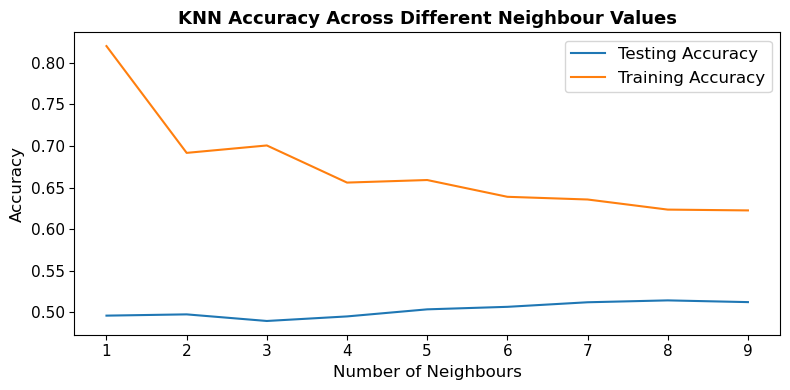

In [118]:
# Plotting model performance
plt.figure(figsize=(8, 4))

plt.title(
    'KNN Accuracy Across Different Neighbour Values',
    fontsize=13,
    fontweight='bold'
)

plt.plot(
    neighbors,
    test_accuracy,
    label='Testing Accuracy'
)

plt.plot(
    neighbors,
    train_accuracy,
    label='Training Accuracy'
)

plt.legend(prop={'size': 12})

plt.xlabel(
    'Number of Neighbours',
    fontsize=12
)

plt.ylabel(
    'Accuracy',
    fontsize=12
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()

The graph compares training and testing accuracy across different neighbour values (`k`), helping identify a suitable balance between underfitting and overfitting.

In [119]:
# Creating and training the final KNN model
knn = KNeighborsClassifier(
    n_neighbors=8
)

knn.fit(X_train, y_train)

train_accuracy[i] = knn.score(
    X_train,
    y_train
)

test_accuracy[i] = knn.score(
    X_test,
    y_test
)

### Model Evaluation

In [120]:
# Displaying testing accuracy
print(test_accuracy)

[0.49622071 0.49773243 0.48979592 0.49527589 0.50377929 0.50680272
 0.51228269 0.51455026 0.51455026]


The KNN model achieved testing accuracy values slightly above 50%, with the best result occurring at `k=8`. This represents the strongest predictive performance among the evaluated machine learning models.

In [121]:
from sklearn.metrics import confusion_matrix

# Predicting test results
prediction = knn.predict(X_test)

# Confusion matrix
confusion_matrix(y_test, prediction)

array([[1779,  869],
       [1700,  944]], dtype=int64)

The confusion matrix summarises the number of correctly and incorrectly classified observations across both target classes.

In [122]:
from sklearn.metrics import classification_report

# Classification report
print(
    classification_report(
        y_test,
        prediction
    )
)

              precision    recall  f1-score   support

           1       0.51      0.67      0.58      2648
           2       0.52      0.36      0.42      2644

    accuracy                           0.51      5292
   macro avg       0.52      0.51      0.50      5292
weighted avg       0.52      0.51      0.50      5292



The classification report shows similar precision across both classes, but recall is higher for class `1` than class `2`. This indicates that the model identifies class `1` more effectively than class `2`.

In [126]:
# KNN testing accuracy
test_knn_acc = knn.score(
    X_test,
    y_test
)

print(test_knn_acc)

0.5145502645502645


## Conclusion

The K-Nearest Neighbours (KNN) model achieved the strongest overall predictive performance among the evaluated machine learning models, with an accuracy of approximately `51%`.

The model demonstrated moderate predictive performance, although recall differences between the two classes indicate some imbalance in classification behaviour.

Although the predictive performance remains moderate, the KNN algorithm showed slightly better generalisation capability compared to the Logistic Regression, Random Forest, and Support Vector Classifier models.

## Model Performance Comparison

In [127]:
# Comparing model performance
models = pd.DataFrame({
    'ML Models': [
        'Logistic Regression',
        'Random Forest Classifier',
        'Support Vector Classifier (SVC)',
        'K-Nearest Neighbours (KNN)'
    ],
    'Score': [
        log_reg_acc,
        ran_clf_acc,
        accuracy,
        test_knn_acc
    ]
})

models.sort_values(
    by='Score',
    ascending=False
)

,ML Models,Score
3,K-Nearest Neighbours (KNN),0.514550
2,Support Vector Classifier (SVC),0.486017
0,Logistic Regression,0.477324
1,Random Forest Classifier,0.428382


## Overall Machine Learning Conclusion

Several machine learning algorithms were evaluated to predict gender categories using demographic and population-related variables from the dataset.

Among the evaluated models, the K-Nearest Neighbours (KNN) algorithm achieved the strongest predictive performance, although the overall accuracy levels across all models remained moderate.

The results suggest that the available features contain limited predictive power for accurately classifying the target variable. Additional feature engineering, alternative modelling approaches, or more informative demographic variables may help improve predictive performance in future analyses.

## Cross Validation and Hyperparameter Tuning

The following procedures were applied to improve model reliability and optimise predictive performance across the evaluated machine learning algorithms.

In [132]:
# Importing Libraries
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

### Logistic Regression Hyperparameter Tuning

In [133]:
log_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

log_params = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['liblinear', 'lbfgs']
}

log_grid = GridSearchCV(
    log_pipeline,
    log_params,
    cv=5,
    scoring='accuracy'
)

log_grid.fit(X, y)

print("Best Logistic Regression Score:", log_grid.best_score_)
print("Best Parameters:", log_grid.best_params_)

Best Logistic Regression Score: 0.47386621315192745
Best Parameters: {'model__C': 0.01, 'model__solver': 'liblinear'}


The tuned Logistic Regression model achieved a cross-validation accuracy of approximately `47.39%`. The best-performing configuration used a lower regularisation parameter (`C=0.01`) with the `liblinear` solver, suggesting that stronger regularisation slightly improved model generalisation.

### Random Forest Hyperparameter Tuning

In [134]:
rf_model = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    rf_model,
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X, y)

print("Best Random Forest Score:", rf_grid.best_score_)
print("Best Parameters:", rf_grid.best_params_)

Best Random Forest Score: 0.4627551020408164
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


The tuned Random Forest model achieved a cross-validation accuracy of approximately `46.28%`. The selected hyperparameters indicate that limiting tree complexity helped reduce overfitting, although the model continued to demonstrate weaker predictive performance compared to the other evaluated algorithms.

### Support Vector Classifier (SVC) Hyperparameter Tuning

In [135]:
svc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC())
])

svc_params = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale', 'auto']
}

svc_grid = GridSearchCV(
    svc_pipeline,
    svc_params,
    cv=5,
    scoring='accuracy'
)

svc_grid.fit(X, y)

print("Best SVC Score:", svc_grid.best_score_)
print("Best Parameters:", svc_grid.best_params_)

Best SVC Score: 0.47556689342403635
Best Parameters: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}


The tuned Support Vector Classifier (SVC) achieved a cross-validation accuracy of approximately `47.56%`. The optimal configuration used a linear kernel with a smaller regularisation parameter, indicating that simpler decision boundaries provided better generalisation performance for this dataset.

### K-Nearest Neighbours (KNN) Hyperparameter Tuning

In [136]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

knn_params = {
    'model__n_neighbors': range(1, 21),
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    knn_pipeline,
    knn_params,
    cv=5,
    scoring='accuracy'
)

knn_grid.fit(X, y)

print("Best KNN Score:", knn_grid.best_score_)
print("Best Parameters:", knn_grid.best_params_)

Best KNN Score: 0.48231292517006796
Best Parameters: {'model__metric': 'euclidean', 'model__n_neighbors': 17, 'model__weights': 'uniform'}


The tuned K-Nearest Neighbours (KNN) model achieved the highest cross-validation accuracy of approximately `48.23%`. The optimal configuration used `17` neighbours with Euclidean distance and uniform weighting, suggesting that smoother neighbourhood boundaries improved predictive stability.

### Comparing Tuned Model Performance

In [137]:
tuned_models = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'SVC',
        'KNN'
    ],
    'Best Cross-Validation Score': [
        log_grid.best_score_,
        rf_grid.best_score_,
        svc_grid.best_score_,
        knn_grid.best_score_
    ]
})

tuned_models.sort_values(
    by='Best Cross-Validation Score',
    ascending=False
)

,Model,Best Cross-Validation Score
3,KNN,0.482313
2,SVC,0.475567
0,Logistic Regression,0.473866
1,Random Forest,0.462755


## Overall Tuned Model Comparison

The cross-validation results indicate that the K-Nearest Neighbours (KNN) algorithm produced the strongest overall predictive performance after hyperparameter tuning, followed closely by the Support Vector Classifier (SVC) and Logistic Regression models.

Although hyperparameter tuning slightly improved model stability and evaluation reliability, all models continued to demonstrate moderate predictive capability, suggesting that the available demographic features provide limited separability for the target variable.

## Improvement Opportunities

The moderate predictive performance across all evaluated models suggests that the available demographic variables provide limited separability for gender classification.

Future improvements could include:
- Advanced feature engineering techniques
- Additional demographic or socioeconomic variables
- More detailed geographic indicators
- Further hyperparameter optimisation
- Feature selection methods
- Testing more advanced machine learning algorithms

These improvements may help increase predictive capability and improve model generalisation performance.